In [ ]:
"""
google drive
"""
from google.colab import drive

drive.mount("/content/drive")


"""
output directory
"""
OUTPUT_DIR = "/content/drive/MyDrive/riboMoE_outputs/ablation"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print(
    f"All outputs will be saved to: {OUTPUT_DIR}"
)

Mounted at /content/drive
All outputs will be saved to: /content/drive/MyDrive/riboMoE_outputs/ablation


In [ ]:
"""
libraries
"""
import os
import gc
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.distributions.normal import Normal
from torch.utils.data import DataLoader, TensorDataset

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)


"""
settings
"""

RANDOM_SEED = 42

EPOCHS = 100
BATCH_SIZE = 128

LEARNING_RATE = 1e-4

L1_REG = 0.0
L2_REG = 1e-4

MOE_NUM_EXPERTS = 10
MOE_HIDDEN_SIZE = 64
MOE_TOP_K = 4
DENSE_HIDDEN_SIZE = 512
DENSE_DROPOUT = 0.30

DATA_CSV = (
    "/content/drive/MyDrive/balanced_dataset.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


"""
random seed
"""
def set_random_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_random_seed(RANDOM_SEED)


"""
device
"""
DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

Device: cuda


In [ ]:
"""
load dataset
"""
df = pd.read_csv(DATA_CSV)

df = df.dropna(
    subset=["label"]
).reset_index(drop=True)

print("Dataset shape:", df.shape)

print(
    "\nLabel counts:"
)

print(
    df["label"].value_counts()
)

Dataset shape: (55024, 54)

Label counts:
label
0.0    27512
1.0    27512
Name: count, dtype: int64


In [ ]:
"""
numerical features
"""
NUMERICAL_FEATURES = [
    "salt_molarity",
    "temperature (Celsius)",
    "trigger_target_binding_percentage",
    "switch_energy",
    "target_energy",
    "reporter_energy",
    "complex_energy",
    "switch_gc",
    "switch_at",
    "target_gc",
    "target_at",
    "reporter_gc",
    "reporter_at",
    "complex_gc",
    "complex_at",
    "switch_ensemble_defect",
    "target_ensemble_defect",
    "reporter_ensemble_defect",
    "complex_ensemble_defect",
    "switch_single_strandedness",
    "target_single_strandedness",
    "reporter_single_strandedness",
    "complex_single_strandedness",
    "trigger_single_strandedness",
    "rbs_location",
    "loop_energy"
]


missing_features = [
    feature
    for feature in NUMERICAL_FEATURES
    if feature not in df.columns
]

if missing_features:

    raise ValueError(
        f"Missing features: {missing_features}"
    )


df[NUMERICAL_FEATURES] = (
    df[NUMERICAL_FEATURES]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
    .fillna(0)
)

NameError: name 'df' is not defined

In [ ]:
"""
one-hot sequence encoding
"""
def one_hot_encode_sequences(
    sequences,
    max_length=210
):

    base_to_vector = {
        "A": [1, 0, 0, 0],
        "C": [0, 1, 0, 0],
        "G": [0, 0, 1, 0],
        "T": [0, 0, 0, 1],
        "U": [0, 0, 0, 1],
        "N": [0, 0, 0, 0]
    }

    encoded_sequences = []

    for sequence in sequences:

        sequence = str(sequence).upper()

        sequence = (
            sequence[:max_length]
            .ljust(
                max_length,
                "N"
            )
        )

        encoded_sequence = [
            base_to_vector.get(
                base,
                [0, 0, 0, 0]
            )
            for base in sequence
        ]

        encoded_sequences.append(
            np.asarray(
                encoded_sequence,
                dtype=np.float32
            ).flatten()
        )

    return np.asarray(
        encoded_sequences,
        dtype=np.float32
    )


encoded_sequences = one_hot_encode_sequences(
    df["complex_nucelotides"],
    max_length=210
)


encoded_sequence_df = pd.DataFrame(
    encoded_sequences,
    columns=[
        f"base_{i}"
        for i in range(
            encoded_sequences.shape[1]
        )
    ]
)


print(
    "Sequence feature shape:",
    encoded_sequence_df.shape
)

Sequence feature shape: (55024, 840)


In [ ]:
"""
labels
"""
y = (
    df["label"]
    .astype(int)
    .to_numpy()
)


"""
fixed independent test split
"""
all_indices = np.arange(
    len(df)
)

train_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=RANDOM_SEED
)

y_train = y[
    train_indices
]

y_test = y[
    test_indices
]


print(
    "Train samples:",
    len(train_indices)
)

print(
    "Independent test samples:",
    len(test_indices)
)

Train samples: 44019
Independent test samples: 11005


In [ ]:
"""
rank numerical features using training data only
"""
feature_auc_results = []


for feature in NUMERICAL_FEATURES:

    values = (
        df.iloc[
            train_indices
        ][feature]
        .to_numpy()
    )

    auc = roc_auc_score(
        y_train,
        values
    )

    auc = max(
        auc,
        1 - auc
    )

    feature_auc_results.append(
        {
            "feature": feature,
            "auc": auc
        }
    )


feature_auc_df = (
    pd.DataFrame(
        feature_auc_results
    )
    .sort_values(
        "auc",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


ABLATION_ORDER = (
    feature_auc_df[
        "feature"
    ]
    .tolist()
)


print(
    feature_auc_df.to_string(
        index=False
    )
)


feature_auc_df.to_csv(
    f"{OUTPUT_DIR}/feature_ablation_order.csv",
    index=False
)

                          feature      auc
                  reporter_energy 1.000000
         reporter_ensemble_defect 1.000000
     reporter_single_strandedness 1.000000
trigger_target_binding_percentage 0.998927
                   complex_energy 0.981920
      complex_single_strandedness 0.966281
                     rbs_location 0.957276
          complex_ensemble_defect 0.704505
                        switch_at 0.692645
                        switch_gc 0.692645
                       complex_at 0.674147
                       complex_gc 0.674147
       switch_single_strandedness 0.608199
                    switch_energy 0.550623
           switch_ensemble_defect 0.546730
           target_ensemble_defect 0.503801
                    target_energy 0.502698
       target_single_strandedness 0.502584
      trigger_single_strandedness 0.501296
                        target_at 0.500102
                        target_gc 0.500102
            temperature (Celsius) 0.500000
           

In [ ]:
"""
ablation amounts
"""
ABLATION_COUNTS = [
    0,
    4,
    8,
    12,
    16,
    20,
    24
]


print(
    "Ablation counts:",
    ABLATION_COUNTS
)

Ablation counts: [0, 4, 8, 12, 16, 20, 24]


In [ ]:
"""
build ablated dataset
"""
def get_ablation_data(
    number_removed
):

    removed_features = (
        ABLATION_ORDER[
            :number_removed
        ]
    )

    remaining_numerical_features = [
        feature
        for feature in NUMERICAL_FEATURES
        if feature not in removed_features
    ]


    numerical_df = (
        df[
            remaining_numerical_features
        ]
        .astype(
            np.float32
        )
        .reset_index(
            drop=True
        )
    )


    X_df = pd.concat(
        [
            numerical_df,
            encoded_sequence_df
        ],
        axis=1
    )


    X_train = (
        X_df.iloc[
            train_indices
        ]
        .to_numpy(
            dtype=np.float32
        )
    )


    X_test = (
        X_df.iloc[
            test_indices
        ]
        .to_numpy(
            dtype=np.float32
        )
    )


    return (
        X_train,
        X_test,
        remaining_numerical_features,
        removed_features
    )

In [ ]:
"""
dense model
"""
class DenseClassifier(
    nn.Module
):

    def __init__(
        self,
        input_size,
        hidden_size=512,
        dropout_prob=0.30
    ):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(
                input_size,
                hidden_size
            ),

            nn.LayerNorm(
                hidden_size
            ),

            nn.LeakyReLU(
                inplace=True
            ),

            nn.Dropout(
                dropout_prob
            ),

            nn.Linear(
                hidden_size,
                hidden_size // 2
            ),

            nn.LayerNorm(
                hidden_size // 2
            ),

            nn.LeakyReLU(
                inplace=True
            ),

            nn.Dropout(
                dropout_prob
            ),

            nn.Linear(
                hidden_size // 2,
                1
            )
        )


    def forward(
        self,
        x
    ):

        return self.net(
            x
        ).squeeze(-1)

In [ ]:
"""
moe experts
"""
class NumericalExpert(
    nn.Module
):

    def __init__(
        self,
        input_size,
        output_size,
        hidden_size
    ):

        super().__init__()

        self.fc1 = nn.Linear(
            input_size,
            hidden_size
        )

        self.fc2 = nn.Linear(
            hidden_size,
            output_size
        )

        self.relu = nn.ReLU()


    def forward(
        self,
        x
    ):

        x = self.fc1(
            x
        )

        x = self.relu(
            x
        )

        return self.fc2(
            x
        )


class SequenceExpert(
    nn.Module
):

    def __init__(
        self,
        output_size,
        hidden_size
    ):

        super().__init__()

        self.embedding = nn.Linear(
            4,
            hidden_size
        )

        self.pos_encoding = nn.Parameter(
            torch.randn(
                1,
                210,
                hidden_size
            )
        )

        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=4,
            batch_first=True,
            dropout=0.1
        )

        self.dropout = nn.Dropout(
            0.1
        )

        self.fc = nn.Linear(
            hidden_size,
            output_size
        )


    def forward(
        self,
        x
    ):

        x = (
            self.embedding(
                x
            )
            +
            self.pos_encoding[
                :,
                :x.size(1),
                :
            ]
        )

        attention_output, _ = self.attention(
            x,
            x,
            x
        )

        attention_output = self.dropout(
            attention_output
        )

        pooled = attention_output.mean(
            dim=1
        )

        return self.fc(
            pooled
        )

In [ ]:
"""
sparse dispatcher
"""
class SparseDispatcher(object):

    def __init__(
        self,
        num_experts,
        gates
    ):

        self._gates = gates
        self._num_experts = num_experts

        sorted_experts, index_sorted_experts = (
            torch.nonzero(gates).sort(0)
        )

        _, self._expert_index = (
            sorted_experts.split(
                1,
                dim=1
            )
        )

        self._batch_index = torch.nonzero(
            gates
        )[
            index_sorted_experts[:, 1],
            0
        ]

        self._part_sizes = (
            (gates > 0)
            .sum(0)
            .tolist()
        )

        gates_exp = gates[
            self._batch_index.flatten()
        ]

        self._nonzero_gates = torch.gather(
            gates_exp,
            1,
            self._expert_index
        )


    def dispatch(
        self,
        inp
    ):

        inp_exp = inp[
            self._batch_index
        ].squeeze(1)

        return torch.split(
            inp_exp,
            self._part_sizes,
            dim=0
        )


    def combine(
        self,
        expert_out,
        multiply_by_gates=True
    ):

        stitched = torch.cat(
            expert_out,
            0
        )

        if multiply_by_gates:

            stitched = stitched.mul(
                self._nonzero_gates
            )

        zeros = torch.zeros(
            self._gates.size(0),
            expert_out[-1].size(1),
            requires_grad=True,
            device=stitched.device
        )

        combined = zeros.index_add(
            0,
            self._batch_index,
            stitched.float()
        )

        return combined


    def expert_to_gates(
        self
    ):

        return torch.split(
            self._nonzero_gates,
            self._part_sizes,
            dim=0
        )


"""
sequence expert
"""
class Sequence(nn.Module):

    def __init__(
        self,
        input_size,
        output_size,
        hidden_size
    ):

        super(
            Sequence,
            self
        ).__init__()

        self.embedding = nn.Linear(
            input_size,
            hidden_size
        )

        self.pos_encoding = nn.Parameter(
            torch.randn(
                1,
                210,
                hidden_size
            )
        )

        self.attn = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=4,
            batch_first=True,
            dropout=0.1
        )

        self.fc = nn.Linear(
            hidden_size,
            output_size
        )

        self.soft = nn.Softmax(1)

        self.dropout = nn.Dropout(
            p=0.1
        )


    def forward(
        self,
        x
    ):

        if x.dim() == 2:

            x = x.view(
                x.size(0),
                210,
                4
            )

        x = (
            self.embedding(x)
            +
            self.pos_encoding[
                :,
                :x.size(1),
                :
            ]
        )

        attn_output, _ = self.attn(
            x,
            x,
            x
        )

        attn_output = self.dropout(
            attn_output
        )

        pooled = attn_output.mean(
            dim=1
        )

        out = self.fc(
            pooled
        )

        return out


"""
mlp expert
"""
class MLP(nn.Module):

    def __init__(
        self,
        input_size,
        output_size,
        hidden_size
    ):

        super(
            MLP,
            self
        ).__init__()

        self.fc1 = nn.Linear(
            input_size,
            hidden_size
        )

        self.fc2 = nn.Linear(
            hidden_size,
            output_size
        )

        self.relu = nn.ReLU()

        self.soft = nn.Softmax(1)


    def forward(
        self,
        x
    ):

        out = self.fc1(
            x
        )

        out = self.relu(
            out
        )

        out = self.fc2(
            out
        )

        return out

In [ ]:
"""
mixture of experts
"""
class MoE(nn.Module):

    def __init__(
        self,
        input_size,
        output_size,
        num_experts,
        hidden_size,
        num_numerical_features,
        noisy_gating=True,
        k=4
    ):

        super(MoE, self).__init__()

        self.noisy_gating = noisy_gating
        self.num_experts = num_experts
        self.output_size = output_size
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.k = k

        self.num_numerical_features = (
            num_numerical_features
        )


        self.experts = nn.ModuleList(

            [
                MLP(
                    input_size=num_numerical_features,
                    output_size=output_size,
                    hidden_size=hidden_size
                )

                for _ in range(
                    num_experts - 3
                )
            ]

            +

            [
                Sequence(
                    input_size=4,
                    output_size=output_size,
                    hidden_size=hidden_size
                )

                for _ in range(3)
            ]
        )


        self.w_gate = nn.Parameter(
            torch.zeros(
                input_size,
                num_experts
            ),
            requires_grad=True
        )

        self.w_noise = nn.Parameter(
            torch.zeros(
                input_size,
                num_experts
            ),
            requires_grad=True
        )


        self.softplus = nn.Softplus()

        self.softmax = nn.Softmax(1)

        self.register_buffer(
            "mean",
            torch.tensor([0.0])
        )

        self.register_buffer(
            "std",
            torch.tensor([1.0])
        )


        assert (
            self.k
            <=
            self.num_experts
        )


    def cv_squared(
        self,
        x
    ):

        eps = 1e-10

        if x.shape[0] == 1:

            return torch.tensor(
                [0],
                device=x.device,
                dtype=x.dtype
            )


        return (
            x.float().var()
            /
            (
                x.float().mean() ** 2
                +
                eps
            )
        )


    def _gates_to_load(
        self,
        gates
    ):

        return (
            gates > 0
        ).sum(0)


    def _prob_in_top_k(
        self,
        clean_values,
        noisy_values,
        noise_stddev,
        noisy_top_values
    ):

        batch = clean_values.size(0)

        m = noisy_top_values.size(1)

        top_values_flat = (
            noisy_top_values.flatten()
        )


        threshold_positions_if_in = (

            torch.arange(
                batch,
                device=clean_values.device
            )

            *

            m

            +

            self.k
        )


        threshold_if_in = torch.unsqueeze(

            torch.gather(
                top_values_flat,
                0,
                threshold_positions_if_in
            ),

            1
        )


        is_in = torch.gt(
            noisy_values,
            threshold_if_in
        )


        threshold_positions_if_out = (
            threshold_positions_if_in
            -
            1
        )


        threshold_if_out = torch.unsqueeze(

            torch.gather(
                top_values_flat,
                0,
                threshold_positions_if_out
            ),

            1
        )


        normal = Normal(
            self.mean,
            self.std
        )


        prob_if_in = normal.cdf(

            (
                clean_values
                -
                threshold_if_in
            )

            /

            noise_stddev
        )


        prob_if_out = normal.cdf(

            (
                clean_values
                -
                threshold_if_out
            )

            /

            noise_stddev
        )


        prob = torch.where(
            is_in,
            prob_if_in,
            prob_if_out
        )


        return prob


    def noisy_top_k_gating(
        self,
        x,
        train,
        noise_epsilon=1e-2
    ):

        clean_logits = (
            x
            @
            self.w_gate
        )


        if (
            self.noisy_gating
            and train
        ):

            raw_noise_stddev = (
                x
                @
                self.w_noise
            )


            noise_stddev = (

                self.softplus(
                    raw_noise_stddev
                )

                +

                noise_epsilon
            )


            noisy_logits = (

                clean_logits

                +

                (
                    torch.randn_like(
                        clean_logits
                    )

                    *

                    noise_stddev
                )
            )


            logits = noisy_logits


        else:

            logits = clean_logits


        logits = self.softmax(
            logits
        )


        top_logits, top_indices = (
            logits.topk(

                min(
                    self.k + 1,
                    self.num_experts
                ),

                dim=1
            )
        )


        top_k_logits = (
            top_logits[
                :,
                :self.k
            ]
        )


        top_k_indices = (
            top_indices[
                :,
                :self.k
            ]
        )


        top_k_gates = (

            top_k_logits

            /

            (
                top_k_logits.sum(
                    1,
                    keepdim=True
                )

                +

                1e-6
            )
        )


        zeros = torch.zeros_like(
            logits,
            requires_grad=True
        )


        gates = zeros.scatter(
            1,
            top_k_indices,
            top_k_gates
        )


        if (
            self.noisy_gating
            and self.k < self.num_experts
            and train
        ):

            load = (

                self._prob_in_top_k(
                    clean_logits,
                    noisy_logits,
                    noise_stddev,
                    top_logits
                )

            ).sum(0)


        else:

            load = self._gates_to_load(
                gates
            )


        return (
            gates,
            load
        )


    def forward(
        self,
        x,
        loss_coef=1e-1
    ):

        batch_size = x.size(0)


        """
        split input
        """
        x_num = x[
            :,
            :self.num_numerical_features
        ]


        x_seq = (

            x[
                :,
                self.num_numerical_features:
            ]

            .view(
                batch_size,
                210,
                4
            )
        )


        """
        gating
        """
        gates, load = (
            self.noisy_top_k_gating(
                x,
                self.training
            )
        )


        importance = gates.sum(0)


        loss = (

            self.cv_squared(
                importance
            )

            +

            self.cv_squared(
                load
            )
        )


        loss *= loss_coef


        """
        original sparse dispatcher
        """
        dispatcher = SparseDispatcher(
            self.num_experts,
            gates
        )


        expert_gates = (
            dispatcher.expert_to_gates()
        )


        expert_outputs = []


        for i in range(
            self.num_experts
        ):

            expert = self.experts[i]


            if isinstance(
                expert,
                MLP
            ):

                expert_input = (
                    dispatcher.dispatch(
                        x_num
                    )[i]
                )


            else:

                mask = (
                    gates[
                        :,
                        i
                    ]
                    >
                    0
                )


                expert_input = (
                    x_seq[
                        mask
                    ]
                )


            if expert_input.size(0) > 0:

                out = expert(
                    expert_input
                )

            else:

                out = torch.empty(
                    (
                        0,
                        self.output_size
                    ),
                    device=x.device
                )


            expert_outputs.append(
                out
            )


        y = dispatcher.combine(
            expert_outputs
        )


        return (
            y,
            loss
        )

In [ ]:
"""
evaluation
"""
def calculate_metrics(
    true_labels,
    predictions
):

    return {

        "accuracy":
            accuracy_score(
                true_labels,
                predictions
            ),

        "precision":
            precision_score(
                true_labels,
                predictions,
                zero_division=0
            ),

        "recall":
            recall_score(
                true_labels,
                predictions,
                zero_division=0
            ),

        "f1":
            f1_score(
                true_labels,
                predictions,
                zero_division=0
            )
    }

In [ ]:
"""
random forest
"""
def run_random_forest(
    X_train,
    X_test
):

    model = RandomForestClassifier(

        n_estimators=300,

        max_features="sqrt",

        random_state=RANDOM_SEED,

        n_jobs=-1
    )


    model.fit(
        X_train,
        y_train
    )


    predictions = model.predict(
        X_test
    )


    return calculate_metrics(
        y_test,
        predictions
    )

In [ ]:
"""
decision tree
"""
def run_decision_tree(
    X_train,
    X_test
):

    model = DecisionTreeClassifier(

        max_features="sqrt",

        random_state=RANDOM_SEED
    )


    model.fit(
        X_train,
        y_train
    )


    predictions = model.predict(
        X_test
    )


    return calculate_metrics(
        y_test,
        predictions
    )

In [ ]:
"""
dense model training
"""
def run_dense(
    X_train,
    X_test
):

    set_random_seed(
        RANDOM_SEED
    )


    scaler = StandardScaler()


    X_train_scaled = (
        scaler.fit_transform(
            X_train
        )
        .astype(
            np.float32
        )
    )


    X_test_scaled = (
        scaler.transform(
            X_test
        )
        .astype(
            np.float32
        )
    )


    train_dataset = TensorDataset(

        torch.tensor(
            X_train_scaled,
            dtype=torch.float32
        ),

        torch.tensor(
            y_train,
            dtype=torch.float32
        )
    )


    train_loader = DataLoader(

        train_dataset,

        batch_size=BATCH_SIZE,

        shuffle=True
    )


    model = DenseClassifier(

        input_size=X_train.shape[1],

        hidden_size=DENSE_HIDDEN_SIZE,

        dropout_prob=DENSE_DROPOUT

    ).to(
        DEVICE
    )


    criterion = (
        nn.BCEWithLogitsLoss()
    )


    optimizer = (
        torch.optim.AdamW(

            model.parameters(),

            lr=LEARNING_RATE
        )
    )


    for epoch in range(
        EPOCHS
    ):

        model.train()


        for inputs, targets in train_loader:

            inputs = inputs.to(
                DEVICE
            )

            targets = targets.to(
                DEVICE
            )


            optimizer.zero_grad()


            logits = model(
                inputs
            )


            classification_loss = (
                criterion(
                    logits,
                    targets
                )
            )


            l1_loss = sum(

                torch.sum(
                    torch.abs(
                        parameter
                    )
                )

                for parameter
                in model.parameters()
            )


            l2_loss = sum(

                torch.sum(
                    parameter ** 2
                )

                for parameter
                in model.parameters()
            )


            loss = (

                classification_loss

                +

                L1_REG
                *
                l1_loss

                +

                L2_REG
                *
                l2_loss
            )


            loss.backward()

            optimizer.step()


    model.eval()


    with torch.no_grad():

        X_test_tensor = (
            torch.tensor(
                X_test_scaled,
                dtype=torch.float32
            )
            .to(
                DEVICE
            )
        )


        logits = model(
            X_test_tensor
        )


        probabilities = torch.sigmoid(
            logits
        )


        predictions = (
            probabilities
            >=
            0.5
        ).long()


        predictions = (
            predictions
            .cpu()
            .numpy()
        )


    metrics = calculate_metrics(
        y_test,
        predictions
    )


    del model

    gc.collect()

    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    return metrics

In [ ]:
"""
moe training
"""
def run_moe(
    X_train,
    X_test,
    number_numerical_features
):

    set_random_seed(
        RANDOM_SEED
    )


    scaler = StandardScaler()


    X_train_scaled = (
        scaler.fit_transform(
            X_train
        )
        .astype(
            np.float32
        )
    )


    X_test_scaled = (
        scaler.transform(
            X_test
        )
        .astype(
            np.float32
        )
    )


    train_dataset = TensorDataset(

        torch.tensor(
            X_train_scaled,
            dtype=torch.float32
        ),

        torch.tensor(
            y_train,
            dtype=torch.long
        )
    )


    train_loader = DataLoader(

        train_dataset,

        batch_size=BATCH_SIZE,

        shuffle=True
    )


    model = MoE(
        input_size=X_train.shape[1],
        output_size=2,
        num_experts=MOE_NUM_EXPERTS,
        hidden_size=MOE_HIDDEN_SIZE,

        num_numerical_features=(
            number_numerical_features
        ),

        k=MOE_TOP_K,
        noisy_gating=True
    ).to(
        DEVICE
    )


    criterion = (
        nn.CrossEntropyLoss()
    )


    optimizer = torch.optim.Adam(

        model.parameters(),

        lr=LEARNING_RATE,

        weight_decay=L2_REG
    )


    for epoch in range(
        EPOCHS
    ):

        model.train()


        for inputs, targets in train_loader:

            inputs = inputs.to(
                DEVICE
            )

            targets = targets.to(
                DEVICE
            )


            optimizer.zero_grad()


            logits, auxiliary_loss = model(
                inputs
            )


            classification_loss = (
                criterion(
                    logits,
                    targets
                )
            )


            l1_loss = sum(

                torch.sum(
                    torch.abs(
                        parameter
                    )
                )

                for parameter
                in model.parameters()

                if parameter.requires_grad
            )


            loss = (

                classification_loss

                +

                auxiliary_loss

                +

                L1_REG
                *
                l1_loss
            )


            loss.backward()

            optimizer.step()


    model.eval()


    with torch.no_grad():

        X_test_tensor = (
            torch.tensor(
                X_test_scaled,
                dtype=torch.float32
            )
            .to(
                DEVICE
            )
        )


        logits, _ = model(
            X_test_tensor
        )


        predictions = torch.argmax(
            logits,
            dim=1
        )


        predictions = (
            predictions
            .cpu()
            .numpy()
        )


    metrics = calculate_metrics(
        y_test,
        predictions
    )


    del model

    gc.collect()

    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    return metrics

In [ ]:
"""
load prior ablation results
"""
RESULTS_PATH = (
    f"{OUTPUT_DIR}/ablation_results.csv"
)

if os.path.exists(
    RESULTS_PATH
):

    ablation_results_df = pd.read_csv(
        RESULTS_PATH
    )

    ablation_results = (
        ablation_results_df
        .to_dict(
            "records"
        )
    )

    completed_counts = set(
        ablation_results_df[
            "features_removed"
        ].tolist()
    )

else:

    ablation_results = []

    completed_counts = set()


print(
    "Already completed:",
    sorted(completed_counts)
)

Already completed: [0]


In [ ]:
"""
run ablation study
"""
ablation_results = []


for number_removed in ABLATION_COUNTS:
    if number_removed in completed_counts:

        print(
            f"Skipping {number_removed} "
            "features removed — already completed."
        )

        continue

    print(
        "\n"
        +
        "=" * 50
    )

    print(
        f"Numerical features removed: {number_removed}"
    )

    print(
        "=" * 50
    )


    (
        X_train_ablation,
        X_test_ablation,
        remaining_numerical_features,
        removed_features
    ) = get_ablation_data(
        number_removed
    )


    print(
        "\nRemoved features:"
    )

    print(
        removed_features
    )


    print(
        "\nRemaining numerical features:",
        len(
            remaining_numerical_features
        )
    )


    """
    random forest
    """
    rf_metrics = run_random_forest(
        X_train_ablation,
        X_test_ablation
    )


    print(
        "\nRandom Forest:"
    )

    print(
        rf_metrics
    )


    """
    decision tree
    """
    dt_metrics = run_decision_tree(
        X_train_ablation,
        X_test_ablation
    )


    print(
        "\nDecision Tree:"
    )

    print(
        dt_metrics
    )


    """
    dense
    """
    dense_metrics = run_dense(
        X_train_ablation,
        X_test_ablation
    )


    print(
        "\nDense:"
    )

    print(
        dense_metrics
    )


    """
    moe
    """
    moe_metrics = run_moe(

        X_train_ablation,

        X_test_ablation,

        number_numerical_features=len(
            remaining_numerical_features
        )
    )


    print(
        "\nMoE:"
    )

    print(
        moe_metrics
    )


    result = {

        "features_removed":
            number_removed,

        "removed_features":
            ", ".join(
                removed_features
            ),

        "MoE_accuracy":
            moe_metrics[
                "accuracy"
            ],

        "MoE_f1":
            moe_metrics[
                "f1"
            ],

        "Dense_accuracy":
            dense_metrics[
                "accuracy"
            ],

        "Dense_f1":
            dense_metrics[
                "f1"
            ],

        "Random_Forest_accuracy":
            rf_metrics[
                "accuracy"
            ],

        "Random_Forest_f1":
            rf_metrics[
                "f1"
            ],

        "Decision_Tree_accuracy":
            dt_metrics[
                "accuracy"
            ],

        "Decision_Tree_f1":
            dt_metrics[
                "f1"
            ]
    }


    ablation_results.append(
        result
    )


    ablation_results_df = (
        pd.DataFrame(
            ablation_results
        )
    )


    ablation_results_df.to_csv(

        f"{OUTPUT_DIR}/ablation_results.csv",

        index=False
    )


    print(
        "\nResults saved."
    )

In [ ]:
"""
results
"""
ablation_results_df = pd.DataFrame(
    ablation_results
)

print(
    ablation_results_df.to_string(
        index=False
    )
)

In [ ]:
"""
accuracy ablation figure
"""
plt.figure(
    figsize=(8, 6)
)


plt.plot(

    ablation_results_df[
        "features_removed"
    ],

    ablation_results_df[
        "MoE_accuracy"
    ],

    marker="o",

    linewidth=2,

    label="MoE"
)


plt.plot(

    ablation_results_df[
        "features_removed"
    ],

    ablation_results_df[
        "Dense_accuracy"
    ],

    marker="o",

    linewidth=2,

    label="Dense NN"
)


plt.plot(

    ablation_results_df[
        "features_removed"
    ],

    ablation_results_df[
        "Random_Forest_accuracy"
    ],

    marker="o",

    linewidth=2,

    label="Random Forest"
)


plt.plot(

    ablation_results_df[
        "features_removed"
    ],

    ablation_results_df[
        "Decision_Tree_accuracy"
    ],

    marker="o",

    linewidth=2,

    label="Decision Tree"
)


plt.title(
    "Accuracy vs Input Feature Ablation"
)

plt.xlabel(
    "Numerical Features Removed"
)

plt.ylabel(
    "Independent Test Accuracy"
)

plt.xticks(
    ABLATION_COUNTS
)

plt.ylim(
    0.50,
    1.01
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


plt.savefig(

    f"{OUTPUT_DIR}/feature_ablation_accuracy.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

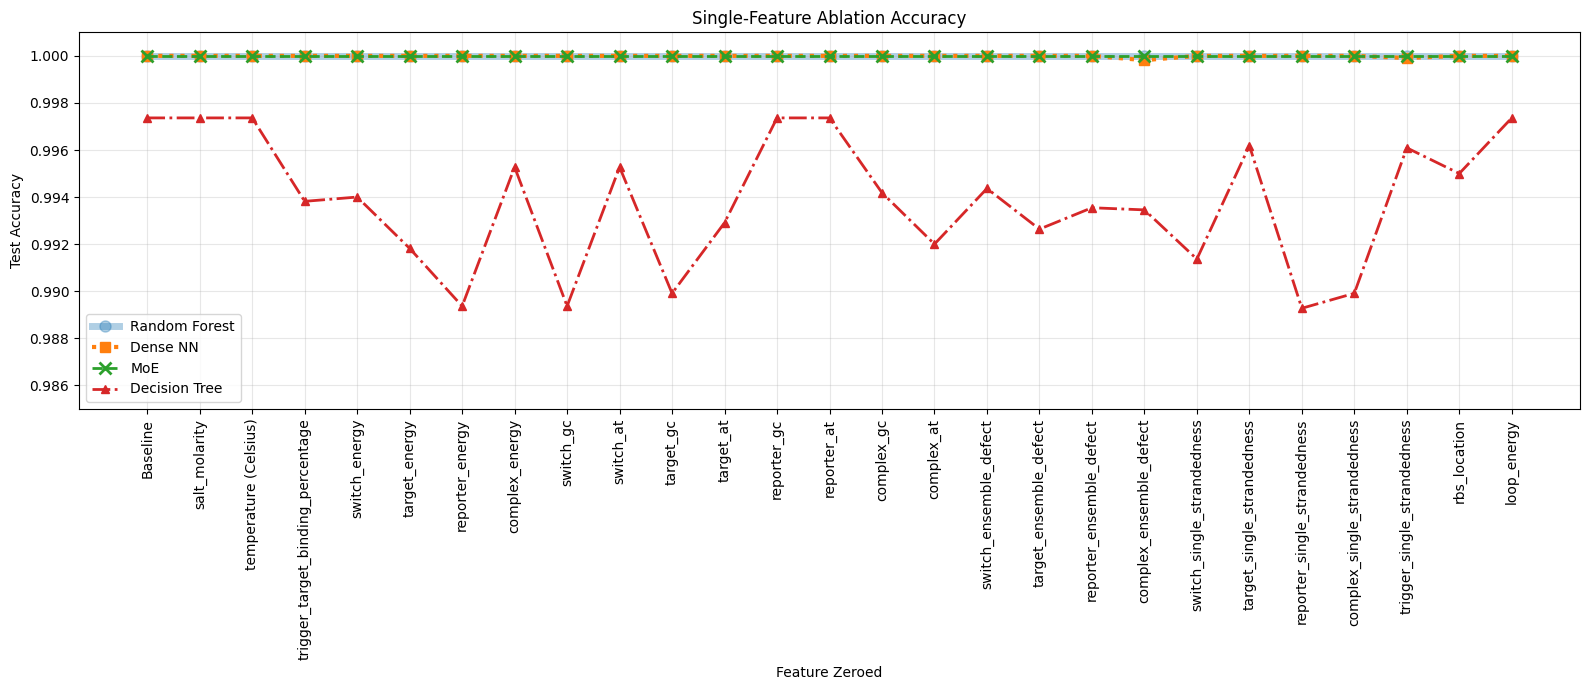

In [ ]:
"""
accuracy ablation figure
"""
results_df = pd.read_csv(
    f"{OUTPUT_DIR}/single_feature_ablation.csv"
)


plt.figure(
    figsize=(16, 7)
)


"""
random forest
"""
plt.plot(
    results_df["zeroed_feature"],
    results_df["Random_Forest_accuracy"],
    marker="o",
    markersize=8,
    linewidth=5,
    alpha=0.35,
    linestyle="-",
    label="Random Forest",
    zorder=1
)


"""
dense
"""
plt.plot(
    results_df["zeroed_feature"],
    results_df["Dense_accuracy"],
    marker="s",
    markersize=7,
    linewidth=3,
    linestyle=":",
    label="Dense NN",
    zorder=2
)


"""
moe
"""
plt.plot(
    results_df["zeroed_feature"],
    results_df["MoE_accuracy"],
    marker="x",
    markersize=8,
    markeredgewidth=2,
    linewidth=2,
    linestyle="--",
    label="MoE",
    zorder=4
)


"""
decision tree
"""
plt.plot(
    results_df["zeroed_feature"],
    results_df["Decision_Tree_accuracy"],
    marker="^",
    markersize=6,
    linewidth=2,
    linestyle="-.",
    label="Decision Tree",
    zorder=3
)


plt.title(
    "Single-Feature Ablation Accuracy"
)

plt.xlabel(
    "Feature Zeroed"
)

plt.ylabel(
    "Test Accuracy"
)

plt.xticks(
    rotation=90
)

plt.ylim(
    0.985,
    1.001
)

plt.legend(
    loc="lower left"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()


plt.savefig(
    f"{OUTPUT_DIR}/single_feature_ablation_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [ ]:
"""
gaussian nb recovery run
"""

import os
import numpy as np
import pandas as pd

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


"""
google drive
"""
drive.mount(
    "/content/drive"
)


OUTPUT_DIR = (
    "/content/drive/MyDrive/"
    "riboMoE_outputs/ablation"
)

RESULTS_PATH = (
    f"{OUTPUT_DIR}/"
    "single_feature_ablation.csv"
)

DATA_CSV = (
    "/content/drive/MyDrive/"
    "balanced_dataset.csv"
)

RANDOM_SEED = 42


"""
numerical features
"""
NUMERICAL_FEATURES = [
    "salt_molarity",
    "temperature (Celsius)",
    "trigger_target_binding_percentage",
    "switch_energy",
    "target_energy",
    "reporter_energy",
    "complex_energy",
    "switch_gc",
    "switch_at",
    "target_gc",
    "target_at",
    "reporter_gc",
    "reporter_at",
    "complex_gc",
    "complex_at",
    "switch_ensemble_defect",
    "target_ensemble_defect",
    "reporter_ensemble_defect",
    "complex_ensemble_defect",
    "switch_single_strandedness",
    "target_single_strandedness",
    "reporter_single_strandedness",
    "complex_single_strandedness",
    "trigger_single_strandedness",
    "rbs_location",
    "loop_energy"
]


"""
load dataset
"""
df = pd.read_csv(
    DATA_CSV
)

df = df.dropna(
    subset=["label"]
).reset_index(
    drop=True
)

df[
    NUMERICAL_FEATURES
] = (
    df[
        NUMERICAL_FEATURES
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
    .fillna(0)
)


"""
one-hot sequence encoding
"""
def one_hot_encode_sequences(
    sequences,
    max_length=210
):

    base_to_vector = {
        "A": [1, 0, 0, 0],
        "C": [0, 1, 0, 0],
        "G": [0, 0, 1, 0],
        "T": [0, 0, 0, 1],
        "U": [0, 0, 0, 1],
        "N": [0, 0, 0, 0]
    }

    encoded_sequences = []

    for sequence in sequences:

        sequence = str(
            sequence
        ).upper()

        sequence = (
            sequence[
                :max_length
            ]
            .ljust(
                max_length,
                "N"
            )
        )

        encoded_sequence = [
            base_to_vector.get(
                base,
                [0, 0, 0, 0]
            )
            for base in sequence
        ]

        encoded_sequences.append(
            np.asarray(
                encoded_sequence,
                dtype=np.float32
            ).flatten()
        )

    return np.asarray(
        encoded_sequences,
        dtype=np.float32
    )


encoded_sequences = (
    one_hot_encode_sequences(
        df[
            "complex_nucelotides"
        ],
        max_length=210
    )
)

encoded_sequence_df = (
    pd.DataFrame(
        encoded_sequences
    )
)


"""
same train/test split
"""
y = (
    df["label"]
    .astype(int)
    .to_numpy()
)

all_indices = np.arange(
    len(df)
)

train_indices, test_indices = (
    train_test_split(
        all_indices,
        test_size=0.20,
        random_state=RANDOM_SEED
    )
)

y_train = y[
    train_indices
]

y_test = y[
    test_indices
]


"""
build zeroed dataset
"""
def get_zeroed_feature_data(
    feature_to_zero=None
):

    numerical_df = (
        df[
            NUMERICAL_FEATURES
        ]
        .astype(
            np.float32
        )
        .reset_index(
            drop=True
        )
        .copy()
    )

    if feature_to_zero is not None:

        numerical_df[
            feature_to_zero
        ] = 0.0

    X_df = pd.concat(
        [
            numerical_df,
            encoded_sequence_df
        ],
        axis=1
    )

    X_train = (
        X_df.iloc[
            train_indices
        ]
        .to_numpy(
            dtype=np.float32
        )
    )

    X_test = (
        X_df.iloc[
            test_indices
        ]
        .to_numpy(
            dtype=np.float32
        )
    )

    return (
        X_train,
        X_test
    )


"""
evaluation
"""
def calculate_metrics(
    true_labels,
    predictions
):

    return {

        "accuracy":
            accuracy_score(
                true_labels,
                predictions
            ),

        "precision":
            precision_score(
                true_labels,
                predictions,
                zero_division=0
            ),

        "recall":
            recall_score(
                true_labels,
                predictions,
                zero_division=0
            ),

        "f1":
            f1_score(
                true_labels,
                predictions,
                zero_division=0
            )
    }


"""
gaussian naive bayes
"""
def run_gaussian_nb(
    X_train,
    X_test
):

    scaler = StandardScaler()

    X_train_scaled = (
        scaler.fit_transform(
            X_train
        )
    )

    X_test_scaled = (
        scaler.transform(
            X_test
        )
    )

    model = GaussianNB(
        var_smoothing=1e-9
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    predictions = model.predict(
        X_test_scaled
    )

    return calculate_metrics(
        y_test,
        predictions
    )


"""
load existing four-model results
"""
results_df = pd.read_csv(
    RESULTS_PATH
)

print(
    results_df[
        "zeroed_feature"
    ].tolist()
)


"""
run only gaussian nb
"""
gaussian_accuracies = []
gaussian_f1_scores = []


for feature in results_df[
    "zeroed_feature"
]:

    if feature == "Baseline":

        feature_to_zero = None

    else:

        feature_to_zero = feature


    (
        X_train_ablation,
        X_test_ablation
    ) = get_zeroed_feature_data(
        feature_to_zero
    )


    gaussian_metrics = (
        run_gaussian_nb(
            X_train_ablation,
            X_test_ablation
        )
    )


    gaussian_accuracies.append(
        gaussian_metrics[
            "accuracy"
        ]
    )

    gaussian_f1_scores.append(
        gaussian_metrics[
            "f1"
        ]
    )


    print(
        feature,
        "->",
        round(
            gaussian_metrics[
                "accuracy"
            ],
            6
        )
    )


"""
add gaussian results to existing csv
"""
results_df[
    "Gaussian_NB_accuracy"
] = (
    gaussian_accuracies
)

results_df[
    "Gaussian_NB_f1"
] = (
    gaussian_f1_scores
)


results_df.to_csv(
    RESULTS_PATH,
    index=False
)


print(
    "\nGaussian NB added and saved to:"
)

print(
    RESULTS_PATH
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['Baseline', 'salt_molarity', 'temperature (Celsius)', 'trigger_target_binding_percentage', 'switch_energy', 'target_energy', 'reporter_energy', 'complex_energy', 'switch_gc', 'switch_at', 'target_gc', 'target_at', 'reporter_gc', 'reporter_at', 'complex_gc', 'complex_at', 'switch_ensemble_defect', 'target_ensemble_defect', 'reporter_ensemble_defect', 'complex_ensemble_defect', 'switch_single_strandedness', 'target_single_strandedness', 'reporter_single_strandedness', 'complex_single_strandedness', 'trigger_single_strandedness', 'rbs_location', 'loop_energy']
Baseline -> 1.0
salt_molarity -> 1.0
temperature (Celsius) -> 1.0
trigger_target_binding_percentage -> 1.0
switch_energy -> 1.0
target_energy -> 1.0
reporter_energy -> 1.0
complex_energy -> 1.0
switch_gc -> 1.0
switch_at -> 1.0
target_gc -> 1.0
target_at -> 1.0
reporter_gc -> 1.0
reporter_at -> 1.0
comple

In [ ]:
"""
rank features by decision tree sensitivity
"""
results_df = pd.read_csv(
    f"{OUTPUT_DIR}/single_feature_ablation.csv"
)

dt_baseline = results_df.loc[
    results_df["zeroed_feature"] == "Baseline",
    "Decision_Tree_accuracy"
].iloc[0]


dt_sensitivity_df = (
    results_df[
        results_df["zeroed_feature"]
        != "Baseline"
    ]
    .copy()
)


dt_sensitivity_df[
    "accuracy_drop"
] = (
    dt_baseline
    -
    dt_sensitivity_df[
        "Decision_Tree_accuracy"
    ]
)


dt_sensitivity_df = (
    dt_sensitivity_df
    .sort_values(
        "accuracy_drop",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


DT_SENSITIVITY_ORDER = (
    dt_sensitivity_df[
        "zeroed_feature"
    ]
    .tolist()
)


print(
    dt_sensitivity_df[
        [
            "zeroed_feature",
            "accuracy_drop"
        ]
    ].to_string(
        index=False
    )
)

                   zeroed_feature  accuracy_drop
     reporter_single_strandedness       0.008087
                        switch_gc       0.007996
                  reporter_energy       0.007996
                        target_gc       0.007451
      complex_single_strandedness       0.007451
       switch_single_strandedness       0.005997
                    target_energy       0.005543
                       complex_at       0.005361
           target_ensemble_defect       0.004725
                        target_at       0.004453
          complex_ensemble_defect       0.003907
         reporter_ensemble_defect       0.003816
trigger_target_binding_percentage       0.003544
                    switch_energy       0.003362
                       complex_gc       0.003180
           switch_ensemble_defect       0.002999
                     rbs_location       0.002363
                   complex_energy       0.002090
                        switch_at       0.002090
      trigger_single

In [ ]:
"""
rank features by decision tree sensitivity
"""
single_results_df = pd.read_csv(
    f"{OUTPUT_DIR}/single_feature_ablation.csv"
)

dt_baseline = single_results_df.loc[
    single_results_df["zeroed_feature"] == "Baseline",
    "Decision_Tree_accuracy"
].iloc[0]


dt_sensitivity_df = (
    single_results_df[
        single_results_df["zeroed_feature"]
        != "Baseline"
    ]
    .copy()
)


dt_sensitivity_df[
    "accuracy_drop"
] = (
    dt_baseline
    -
    dt_sensitivity_df[
        "Decision_Tree_accuracy"
    ]
)


dt_sensitivity_df = (
    dt_sensitivity_df
    .sort_values(
        "accuracy_drop",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


DT_SENSITIVITY_ORDER = (
    dt_sensitivity_df[
        "zeroed_feature"
    ]
    .tolist()
)


print(
    dt_sensitivity_df[
        [
            "zeroed_feature",
            "accuracy_drop"
        ]
    ].to_string(
        index=False
    )
)


"""
build cumulatively zeroed dataset
"""
def get_multi_zeroed_feature_data(
    features_to_zero
):

    numerical_df = (
        df[
            NUMERICAL_FEATURES
        ]
        .astype(
            np.float32
        )
        .reset_index(
            drop=True
        )
        .copy()
    )


    for feature in features_to_zero:

        numerical_df[
            feature
        ] = 0.0


    X_df = pd.concat(
        [
            numerical_df,
            encoded_sequence_df
        ],
        axis=1
    )


    X_train = (
        X_df.iloc[
            train_indices
        ]
        .to_numpy(
            dtype=np.float32
        )
    )


    X_test = (
        X_df.iloc[
            test_indices
        ]
        .to_numpy(
            dtype=np.float32
        )
    )


    return (
        X_train,
        X_test
    )


"""
moe cumulative zeroing settings
"""
MOE_ZERO_RESULTS_PATH = (
    f"{OUTPUT_DIR}/"
    "moe_dt_ranked_cumulative_zeroing.csv"
)


if os.path.exists(
    MOE_ZERO_RESULTS_PATH
):

    moe_zero_df = pd.read_csv(
        MOE_ZERO_RESULTS_PATH
    )

    moe_zero_results = (
        moe_zero_df.to_dict(
            "records"
        )
    )

    completed_counts = set(
        moe_zero_df[
            "num_features_zeroed"
        ].tolist()
    )

else:

    moe_zero_results = []

    completed_counts = set()


"""
run moe until accuracy drops below 100%
"""
for number_zeroed in range(
    0,
    len(DT_SENSITIVITY_ORDER) + 1
):

    if number_zeroed in completed_counts:

        print(
            f"Skipping {number_zeroed} "
            "features zeroed - already completed."
        )

        continue


    features_to_zero = (
        DT_SENSITIVITY_ORDER[
            :number_zeroed
        ]
    )


    print(
        "\n"
        +
        "=" * 60
    )

    print(
        f"Features zeroed: {number_zeroed}"
    )

    print(
        features_to_zero
    )

    print(
        "=" * 60
    )


    (
        X_train_zeroed,
        X_test_zeroed
    ) = get_multi_zeroed_feature_data(
        features_to_zero
    )


    moe_metrics = run_moe(
        X_train_zeroed,
        X_test_zeroed,
        number_numerical_features=len(
            NUMERICAL_FEATURES
        )
    )


    print(
        "\nMoE accuracy:",
        moe_metrics[
            "accuracy"
        ]
    )

    print(
        "MoE F1:",
        moe_metrics[
            "f1"
        ]
    )


    result = {

        "num_features_zeroed":
            number_zeroed,

        "zeroed_features":
            ", ".join(
                features_to_zero
            ),

        "MoE_accuracy":
            moe_metrics[
                "accuracy"
            ],

        "MoE_f1":
            moe_metrics[
                "f1"
            ]
    }


    moe_zero_results.append(
        result
    )


    moe_zero_df = pd.DataFrame(
        moe_zero_results
    )


    moe_zero_df.to_csv(
        MOE_ZERO_RESULTS_PATH,
        index=False
    )


    completed_counts.add(
        number_zeroed
    )


    print(
        "Saved to Google Drive."
    )


    if (
        number_zeroed > 0
        and
        moe_metrics["accuracy"] < 1.0
    ):

        print(
            "\nMoE accuracy finally "
            "dropped below 100%."
        )

        print(
            "First drop occurred after "
            f"zeroing {number_zeroed} features."
        )

        print(
            "Features:"
        )

        print(
            features_to_zero
        )

        break

                   zeroed_feature  accuracy_drop
     reporter_single_strandedness       0.008087
                        switch_gc       0.007996
                  reporter_energy       0.007996
                        target_gc       0.007451
      complex_single_strandedness       0.007451
       switch_single_strandedness       0.005997
                    target_energy       0.005543
                       complex_at       0.005361
           target_ensemble_defect       0.004725
                        target_at       0.004453
          complex_ensemble_defect       0.003907
         reporter_ensemble_defect       0.003816
trigger_target_binding_percentage       0.003544
                    switch_energy       0.003362
                       complex_gc       0.003180
           switch_ensemble_defect       0.002999
                     rbs_location       0.002363
                   complex_energy       0.002090
                        switch_at       0.002090
      trigger_single

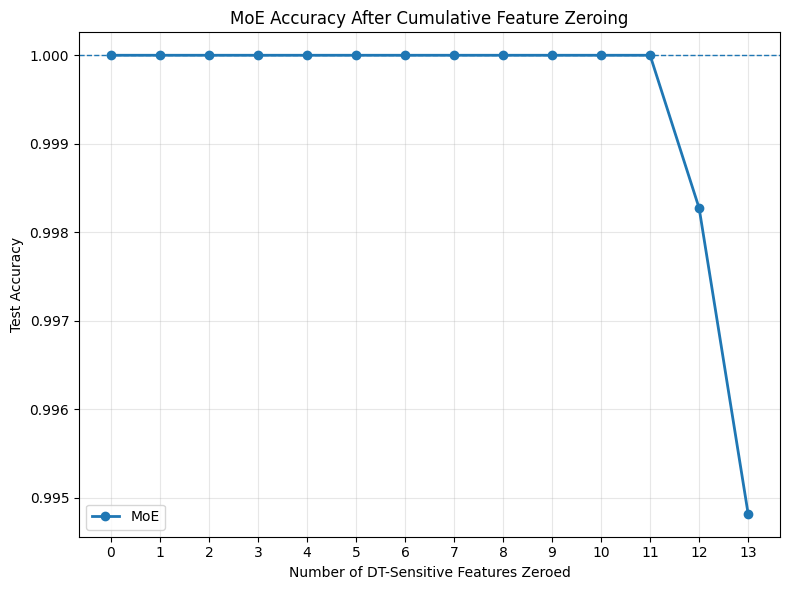

In [ ]:
"""
plot cumulative moe ablation
"""
moe_zero_df = pd.read_csv(
    MOE_ZERO_RESULTS_PATH
)


plt.figure(
    figsize=(8, 6)
)


plt.plot(
    moe_zero_df[
        "num_features_zeroed"
    ],
    moe_zero_df[
        "MoE_accuracy"
    ],
    marker="o",
    linewidth=2,
    label="MoE"
)


plt.axhline(
    1.0,
    linestyle="--",
    linewidth=1
)


plt.title(
    "MoE Accuracy After Cumulative Feature Zeroing"
)

plt.xlabel(
    "Number of DT-Sensitive Features Zeroed"
)

plt.ylabel(
    "Test Accuracy"
)

plt.xticks(
    moe_zero_df[
        "num_features_zeroed"
    ]
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()


plt.savefig(
    f"{OUTPUT_DIR}/moe_dt_ranked_cumulative_zeroing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

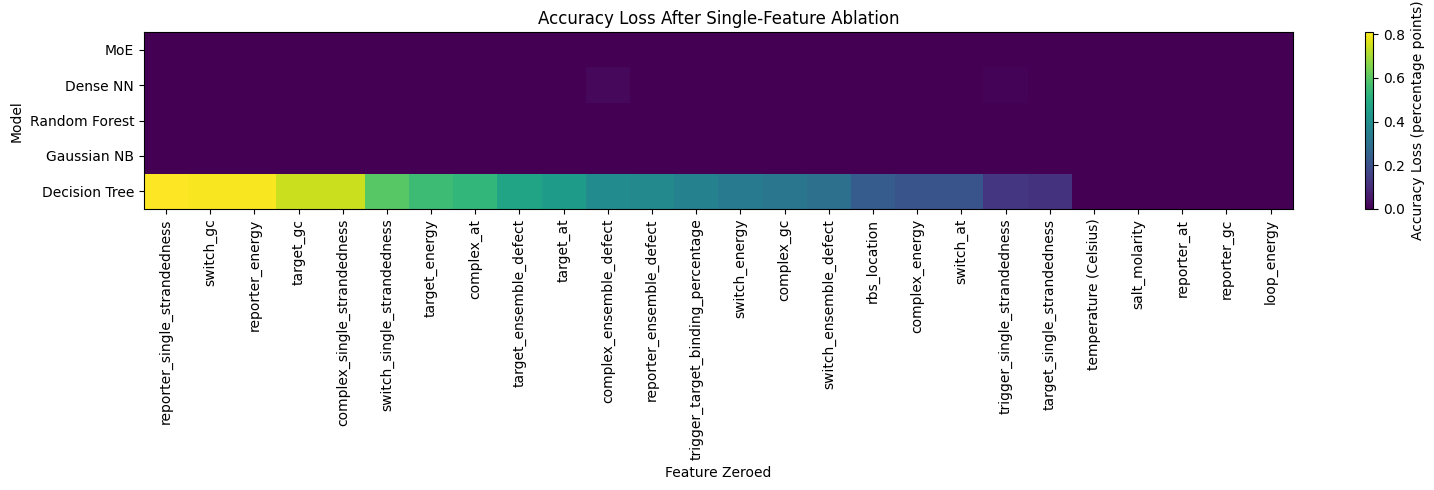

                   zeroed_feature  DT_accuracy_loss
     reporter_single_strandedness          0.808723
                        switch_gc          0.799637
                  reporter_energy          0.799637
                        target_gc          0.745116
      complex_single_strandedness          0.745116
       switch_single_strandedness          0.599727
                    target_energy          0.554294
                       complex_at          0.536120
           target_ensemble_defect          0.472512
                        target_at          0.445252
          complex_ensemble_defect          0.390731
         reporter_ensemble_defect          0.381645
trigger_target_binding_percentage          0.354384
                    switch_energy          0.336211
                       complex_gc          0.318037
           switch_ensemble_defect          0.299864
                     rbs_location          0.236256
                   complex_energy          0.208996
            

In [ ]:
"""
dt-sensitivity sorted heatmap
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


results_df = pd.read_csv(
    f"{OUTPUT_DIR}/single_feature_ablation.csv"
)


models = {
    "MoE": "MoE_accuracy",
    "Dense NN": "Dense_accuracy",
    "Random Forest": "Random_Forest_accuracy",
    "Gaussian NB": "Gaussian_NB_accuracy",
    "Decision Tree": "Decision_Tree_accuracy"
}


"""
remove baseline
"""
feature_df = results_df[
    results_df["zeroed_feature"] != "Baseline"
].copy()


"""
calculate dt sensitivity
"""
dt_baseline = results_df.loc[
    results_df["zeroed_feature"] == "Baseline",
    "Decision_Tree_accuracy"
].iloc[0]


feature_df[
    "DT_accuracy_loss"
] = (
    dt_baseline
    -
    feature_df[
        "Decision_Tree_accuracy"
    ]
) * 100


"""
sort most dt-sensitive to least
"""
feature_df = (
    feature_df
    .sort_values(
        "DT_accuracy_loss",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


"""
calculate accuracy loss for all models
"""
accuracy_loss = []


for model_name, column in models.items():

    baseline = results_df.loc[
        results_df["zeroed_feature"] == "Baseline",
        column
    ].iloc[0]

    loss = (
        baseline
        -
        feature_df[column]
    ) * 100

    accuracy_loss.append(
        loss.to_numpy()
    )


accuracy_loss = np.array(
    accuracy_loss
)


"""
plot heatmap
"""
fig, ax = plt.subplots(
    figsize=(16, 5)
)


image = ax.imshow(
    accuracy_loss,
    aspect="auto"
)


ax.set_xticks(
    np.arange(
        len(feature_df)
    )
)

ax.set_xticklabels(
    feature_df[
        "zeroed_feature"
    ],
    rotation=90
)


ax.set_yticks(
    np.arange(
        len(models)
    )
)

ax.set_yticklabels(
    list(
        models.keys()
    )
)


ax.set_xlabel(
    "Feature Zeroed"
)

ax.set_ylabel(
    "Model"
)

ax.set_title(
    "Accuracy Loss After Single-Feature Ablation"
)


colorbar = fig.colorbar(
    image,
    ax=ax
)

colorbar.set_label(
    "Accuracy Loss (percentage points)"
)


plt.tight_layout()


plt.savefig(
    f"{OUTPUT_DIR}/single_feature_ablation_heatmap_DT_sorted.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


"""
show dt sensitivity order
"""
print(
    feature_df[
        [
            "zeroed_feature",
            "DT_accuracy_loss"
        ]
    ].to_string(
        index=False
    )
)

In [ ]:
"""
recover runtime and continue cumulative moe zeroing
"""

import os
import gc
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.model_selection import train_test_split


"""
google drive
"""
drive.mount(
    "/content/drive"
)


OUTPUT_DIR = (
    "/content/drive/MyDrive/"
    "riboMoE_outputs/ablation"
)

DATA_CSV = (
    "/content/drive/MyDrive/"
    "balanced_dataset.csv"
)

RANDOM_SEED = 42


"""
numerical features
"""
NUMERICAL_FEATURES = [
    "salt_molarity",
    "temperature (Celsius)",
    "trigger_target_binding_percentage",
    "switch_energy",
    "target_energy",
    "reporter_energy",
    "complex_energy",
    "switch_gc",
    "switch_at",
    "target_gc",
    "target_at",
    "reporter_gc",
    "reporter_at",
    "complex_gc",
    "complex_at",
    "switch_ensemble_defect",
    "target_ensemble_defect",
    "reporter_ensemble_defect",
    "complex_ensemble_defect",
    "switch_single_strandedness",
    "target_single_strandedness",
    "reporter_single_strandedness",
    "complex_single_strandedness",
    "trigger_single_strandedness",
    "rbs_location",
    "loop_energy"
]


"""
load dataset
"""
df = pd.read_csv(
    DATA_CSV
)

df = df.dropna(
    subset=["label"]
).reset_index(
    drop=True
)

df[
    NUMERICAL_FEATURES
] = (
    df[
        NUMERICAL_FEATURES
    ]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
    .fillna(0)
)

print(
    "Dataset:",
    df.shape
)


"""
one-hot sequence encoding
"""
def one_hot_encode_sequences(
    sequences,
    max_length=210
):

    base_to_vector = {
        "A": [1, 0, 0, 0],
        "C": [0, 1, 0, 0],
        "G": [0, 0, 1, 0],
        "T": [0, 0, 0, 1],
        "U": [0, 0, 0, 1],
        "N": [0, 0, 0, 0]
    }

    encoded_sequences = []

    for sequence in sequences:

        sequence = str(
            sequence
        ).upper()

        sequence = (
            sequence[
                :max_length
            ]
            .ljust(
                max_length,
                "N"
            )
        )

        encoded_sequence = [
            base_to_vector.get(
                base,
                [0, 0, 0, 0]
            )
            for base in sequence
        ]

        encoded_sequences.append(
            np.asarray(
                encoded_sequence,
                dtype=np.float32
            ).flatten()
        )

    return np.asarray(
        encoded_sequences,
        dtype=np.float32
    )


encoded_sequences = (
    one_hot_encode_sequences(
        df[
            "complex_nucelotides"
        ]
    )
)

encoded_sequence_df = (
    pd.DataFrame(
        encoded_sequences,
        columns=[
            f"base_{i}"
            for i in range(
                encoded_sequences.shape[1]
            )
        ]
    )
)

print(
    "Sequence features:",
    encoded_sequence_df.shape
)


"""
same train/test split
"""
y = (
    df["label"]
    .astype(int)
    .to_numpy()
)

all_indices = np.arange(
    len(df)
)

train_indices, test_indices = (
    train_test_split(
        all_indices,
        test_size=0.20,
        random_state=RANDOM_SEED
    )
)

y_train = y[
    train_indices
]

y_test = y[
    test_indices
]

print(
    "Train:",
    len(train_indices)
)

print(
    "Test:",
    len(test_indices)
)


"""
recover dt sensitivity order
"""
single_results_df = pd.read_csv(
    f"{OUTPUT_DIR}/"
    "single_feature_ablation.csv"
)

dt_baseline = single_results_df.loc[
    single_results_df[
        "zeroed_feature"
    ] == "Baseline",
    "Decision_Tree_accuracy"
].iloc[0]

dt_sensitivity_df = (
    single_results_df[
        single_results_df[
            "zeroed_feature"
        ] != "Baseline"
    ]
    .copy()
)

dt_sensitivity_df[
    "accuracy_drop"
] = (
    dt_baseline
    -
    dt_sensitivity_df[
        "Decision_Tree_accuracy"
    ]
)

dt_sensitivity_df = (
    dt_sensitivity_df
    .sort_values(
        "accuracy_drop",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

DT_SENSITIVITY_ORDER = (
    dt_sensitivity_df[
        "zeroed_feature"
    ]
    .tolist()
)


"""
build cumulatively zeroed dataset
"""
def get_multi_zeroed_feature_data(
    features_to_zero
):

    numerical_df = (
        df[
            NUMERICAL_FEATURES
        ]
        .astype(
            np.float32
        )
        .reset_index(
            drop=True
        )
        .copy()
    )

    for feature in features_to_zero:

        numerical_df[
            feature
        ] = 0.0

    X_df = pd.concat(
        [
            numerical_df,
            encoded_sequence_df
        ],
        axis=1
    )

    X_train = (
        X_df.iloc[
            train_indices
        ]
        .to_numpy(
            dtype=np.float32
        )
    )

    X_test = (
        X_df.iloc[
            test_indices
        ]
        .to_numpy(
            dtype=np.float32
        )
    )

    return (
        X_train,
        X_test
    )


"""
load saved cumulative progress
"""
MOE_ZERO_RESULTS_PATH = (
    f"{OUTPUT_DIR}/"
    "moe_dt_ranked_cumulative_zeroing.csv"
)

moe_zero_df = pd.read_csv(
    MOE_ZERO_RESULTS_PATH
)

moe_zero_results = (
    moe_zero_df
    .to_dict(
        "records"
    )
)

completed_counts = set(
    moe_zero_df[
        "num_features_zeroed"
    ]
    .astype(int)
    .tolist()
)

print(
    "\nAlready completed:",
    sorted(
        completed_counts
    )
)


"""
continue from saved point
"""
if "run_moe" not in globals():

    print(
        "\nDATA RECOVERED SUCCESSFULLY."
    )

    print(
        "run_moe() is not currently loaded "
        "because the runtime restarted."
    )

    print(
        "Run only these existing notebook cells:"
    )

    print(
        "SparseDispatcher -> Sequence -> MLP "
        "-> MoE -> calculate_metrics -> run_moe"
    )

    print(
        "Then rerun THIS cell. "
        "It will still skip 0-16."
    )

else:

    for number_zeroed in range(
        0,
        len(
            DT_SENSITIVITY_ORDER
        ) + 1
    ):

        if number_zeroed in completed_counts:

            print(
                f"Skipping {number_zeroed} "
                "features zeroed - already completed."
            )

            continue


        features_to_zero = (
            DT_SENSITIVITY_ORDER[
                :number_zeroed
            ]
        )


        print(
            "\n"
            +
            "=" * 60
        )

        print(
            f"Number of features zeroed: "
            f"{number_zeroed}/26"
        )

        print(
            "Features zeroed:"
        )

        print(
            features_to_zero
        )

        print(
            "=" * 60
        )


        (
            X_train_zeroed,
            X_test_zeroed
        ) = get_multi_zeroed_feature_data(
            features_to_zero
        )


        moe_metrics = run_moe(
            X_train_zeroed,
            X_test_zeroed,
            number_numerical_features=26
        )


        print(
            "MoE accuracy:",
            moe_metrics[
                "accuracy"
            ]
        )


        result = {

            "num_features_zeroed":
                number_zeroed,

            "last_feature_zeroed":
                (
                    features_to_zero[-1]
                    if number_zeroed > 0
                    else "Baseline"
                ),

            "zeroed_features":
                ", ".join(
                    features_to_zero
                ),

            "MoE_accuracy":
                moe_metrics[
                    "accuracy"
                ],

            "MoE_f1":
                moe_metrics[
                    "f1"
                ]
        }


        moe_zero_results.append(
            result
        )


        moe_zero_df = (
            pd.DataFrame(
                moe_zero_results
            )
            .sort_values(
                "num_features_zeroed"
            )
            .drop_duplicates(
                subset=[
                    "num_features_zeroed"
                ],
                keep="last"
            )
            .reset_index(
                drop=True
            )
        )


        moe_zero_df.to_csv(
            MOE_ZERO_RESULTS_PATH,
            index=False
        )


        completed_counts.add(
            number_zeroed
        )


        print(
            "Saved to Google Drive."
        )


    print(
        "\nFinished through all 26 features."
    )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset: (55024, 54)
Sequence features: (55024, 840)
Train: 44019
Test: 11005

Already completed: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]
Skipping 0 features zeroed - already completed.
Skipping 1 features zeroed - already completed.
Skipping 2 features zeroed - already completed.
Skipping 3 features zeroed - already completed.
Skipping 4 features zeroed - already completed.
Skipping 5 features zeroed - already completed.
Skipping 6 features zeroed - already completed.
Skipping 7 features zeroed - already completed.
Skipping 8 features zeroed - already completed.
Skipping 9 features zeroed - already completed.
Skipping 10 features zeroed - already completed.
Skipping 11 features zeroed - already completed.
Skipping 12 features zeroed - already completed.
Skipping 13 features zeroed - already completed

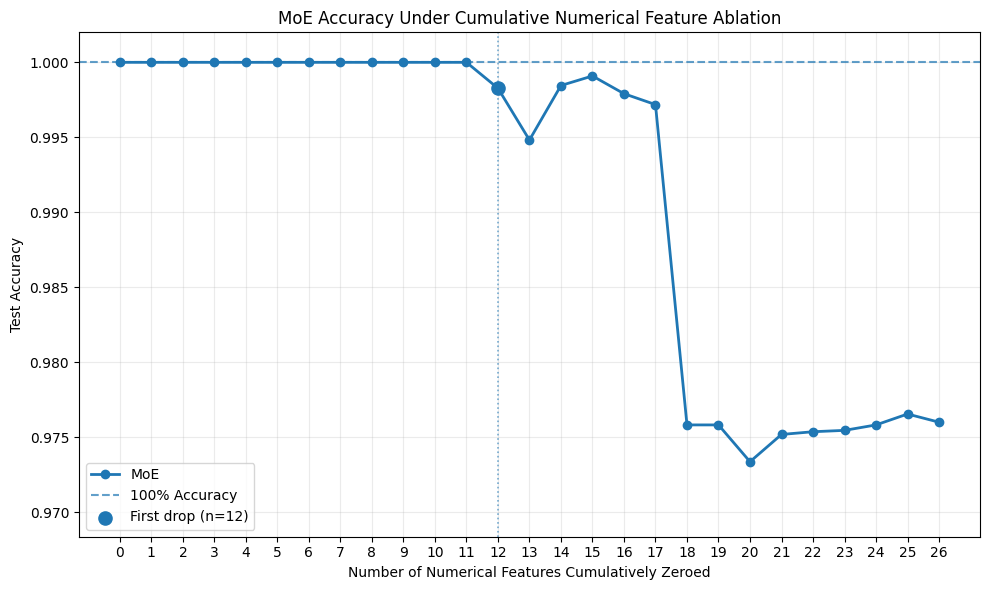

In [ ]:
"""
plot cumulative moe ablation
"""
import pandas as pd
import matplotlib.pyplot as plt


MOE_ZERO_RESULTS_PATH = (
    f"{OUTPUT_DIR}/"
    "moe_dt_ranked_cumulative_zeroing.csv"
)


moe_zero_df = (
    pd.read_csv(
        MOE_ZERO_RESULTS_PATH
    )
    .sort_values(
        "num_features_zeroed"
    )
    .reset_index(
        drop=True
    )
)


"""
find first accuracy drop below 100%
"""
below_100_df = (
    moe_zero_df[
        moe_zero_df[
            "MoE_accuracy"
        ] < 1.0
    ]
)

first_drop_x = None
first_drop_y = None

if len(
    below_100_df
) > 0:

    first_drop_row = (
        below_100_df.iloc[0]
    )

    first_drop_x = int(
        first_drop_row[
            "num_features_zeroed"
        ]
    )

    first_drop_y = float(
        first_drop_row[
            "MoE_accuracy"
        ]
    )


"""
plot
"""
plt.figure(
    figsize=(10, 6)
)


plt.plot(
    moe_zero_df[
        "num_features_zeroed"
    ],
    moe_zero_df[
        "MoE_accuracy"
    ],
    marker="o",
    markersize=6,
    linewidth=2,
    label="MoE"
)


"""
100 percent reference
"""
plt.axhline(
    y=1.0,
    linestyle="--",
    linewidth=1.5,
    alpha=0.7,
    label="100% Accuracy"
)


"""
mark first drop
"""
if first_drop_x is not None:

    plt.scatter(
        first_drop_x,
        first_drop_y,
        s=90,
        zorder=5,
        label=(
            f"First drop "
            f"(n={first_drop_x})"
        )
    )


    plt.axvline(
        x=first_drop_x,
        linestyle=":",
        linewidth=1.2,
        alpha=0.6
    )


plt.title(
    "MoE Accuracy Under Cumulative Numerical Feature Ablation"
)

plt.xlabel(
    "Number of Numerical Features Cumulatively Zeroed"
)

plt.ylabel(
    "Test Accuracy"
)


plt.xticks(
    range(
        0,
        27
    )
)


plt.ylim(
    max(
        0.0,
        moe_zero_df[
            "MoE_accuracy"
        ].min() - 0.005
    ),
    1.002
)


plt.grid(
    alpha=0.25
)

plt.legend(
    loc="lower left"
)

plt.tight_layout()


plt.savefig(
    f"{OUTPUT_DIR}/"
    "moe_cumulative_zeroing_final.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

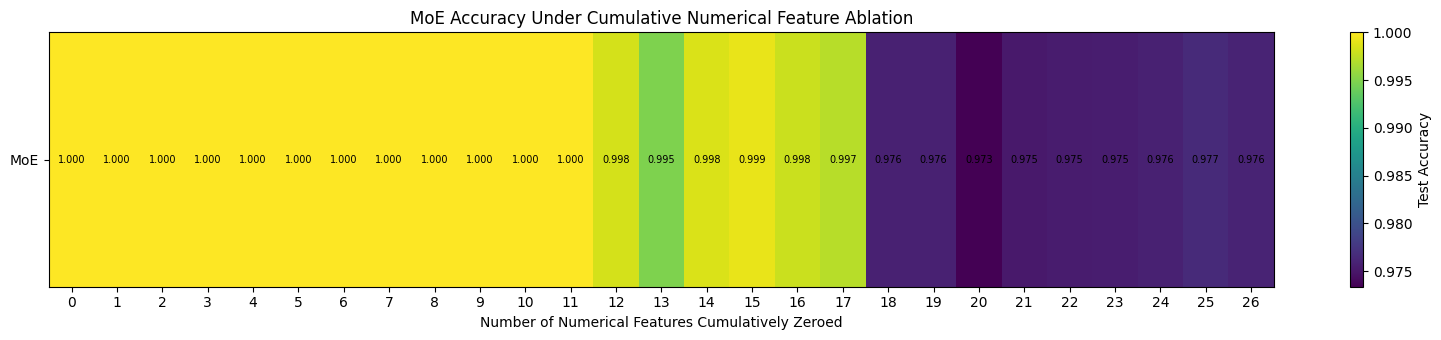

In [ ]:
"""
cumulative moe heatmap
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


MOE_ZERO_RESULTS_PATH = (
    f"{OUTPUT_DIR}/"
    "moe_dt_ranked_cumulative_zeroing.csv"
)


moe_zero_df = (
    pd.read_csv(
        MOE_ZERO_RESULTS_PATH
    )
    .sort_values(
        "num_features_zeroed"
    )
    .reset_index(
        drop=True
    )
)


"""
prepare heatmap values
"""
heatmap_values = (
    moe_zero_df[
        "MoE_accuracy"
    ]
    .to_numpy()
    .reshape(
        1,
        -1
    )
)


"""
plot
"""
fig, ax = plt.subplots(
    figsize=(16, 3.5)
)


image = ax.imshow(
    heatmap_values,
    aspect="auto",
    vmin=heatmap_values.min(),
    vmax=1.0
)


ax.set_xticks(
    np.arange(
        len(
            moe_zero_df
        )
    )
)

ax.set_xticklabels(
    moe_zero_df[
        "num_features_zeroed"
    ].astype(
        str
    )
)


ax.set_yticks(
    [0]
)

ax.set_yticklabels(
    ["MoE"]
)


ax.set_xlabel(
    "Number of Numerical Features Cumulatively Zeroed"
)

ax.set_title(
    "MoE Accuracy Under Cumulative Numerical Feature Ablation"
)


"""
accuracy labels
"""
for i, accuracy in enumerate(
    moe_zero_df[
        "MoE_accuracy"
    ]
):

    ax.text(
        i,
        0,
        f"{accuracy:.3f}",
        ha="center",
        va="center",
        fontsize=7
    )


"""
color bar
"""
colorbar = fig.colorbar(
    image,
    ax=ax
)

colorbar.set_label(
    "Test Accuracy"
)


plt.tight_layout()


plt.savefig(
    f"{OUTPUT_DIR}/"
    "moe_cumulative_zeroing_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

DT-derived cumulative order:
                   zeroed_feature  accuracy_drop
     reporter_single_strandedness       0.008087
                        switch_gc       0.007996
                  reporter_energy       0.007996
                        target_gc       0.007451
      complex_single_strandedness       0.007451
       switch_single_strandedness       0.005997
                    target_energy       0.005543
                       complex_at       0.005361
           target_ensemble_defect       0.004725
                        target_at       0.004453
          complex_ensemble_defect       0.003907
         reporter_ensemble_defect       0.003816
trigger_target_binding_percentage       0.003544
                    switch_energy       0.003362
                       complex_gc       0.003180
           switch_ensemble_defect       0.002999
                     rbs_location       0.002363
                   complex_energy       0.002090
                        switch_at       

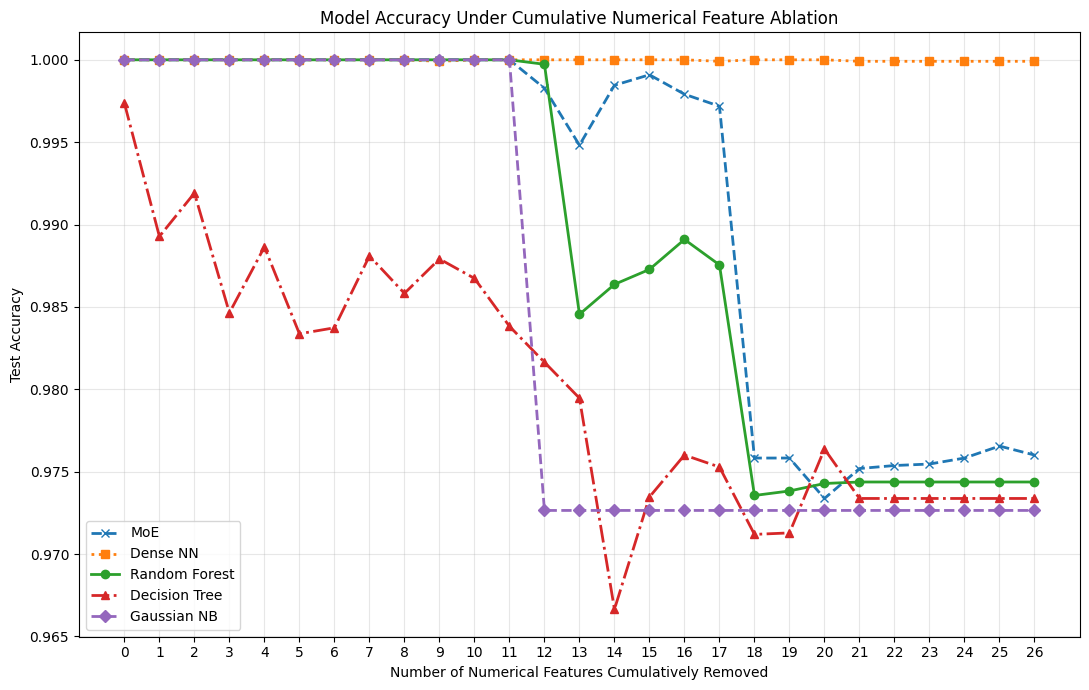

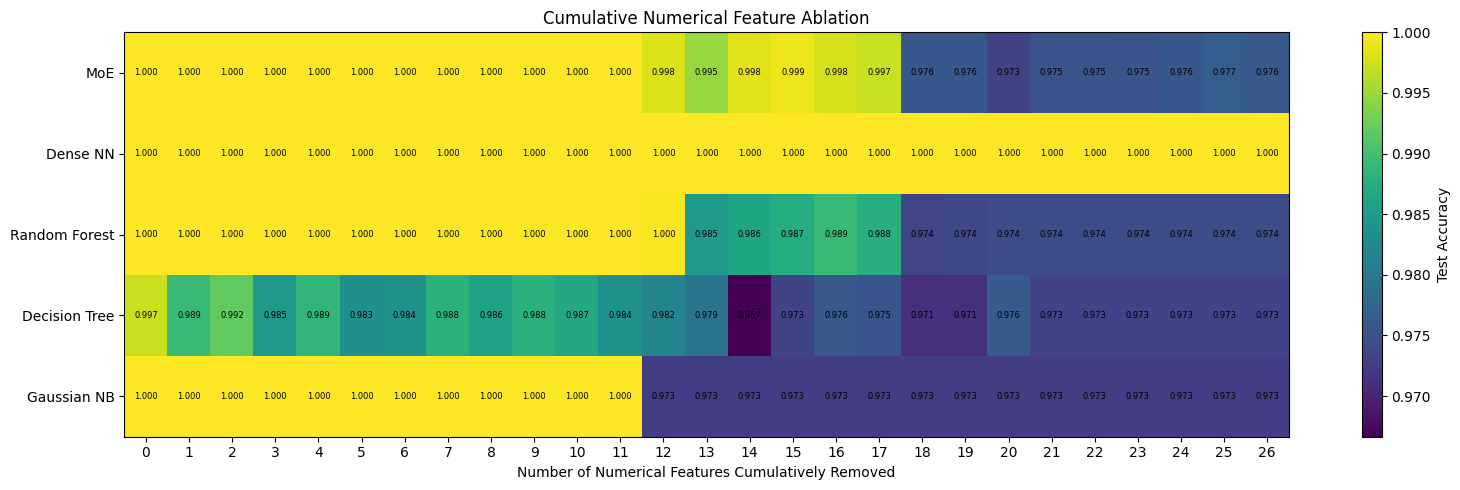

In [ ]:
"""
all five models cumulative ablation
"""

import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler


"""
check required notebook objects
"""
required_objects = [
    "df",
    "encoded_sequence_df",
    "train_indices",
    "test_indices",
    "y_train",
    "y_test",
    "NUMERICAL_FEATURES",
    "run_random_forest",
    "run_decision_tree",
    "run_dense",
    "run_moe",
    "calculate_metrics"
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:

    raise RuntimeError(
        "Run the setup/model cells first. Missing: "
        + ", ".join(missing_objects)
    )


"""
gaussian naive bayes
"""
def run_gaussian_nb(
    X_train,
    X_test
):

    scaler = StandardScaler()

    X_train_scaled = (
        scaler.fit_transform(
            X_train
        )
    )

    X_test_scaled = (
        scaler.transform(
            X_test
        )
    )

    model = GaussianNB(
        var_smoothing=1e-9
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    predictions = model.predict(
        X_test_scaled
    )

    return calculate_metrics(
        y_test,
        predictions
    )


"""
rank features by decision tree sensitivity
"""
single_results_df = pd.read_csv(
    f"{OUTPUT_DIR}/single_feature_ablation.csv"
)

dt_baseline = single_results_df.loc[
    single_results_df[
        "zeroed_feature"
    ] == "Baseline",
    "Decision_Tree_accuracy"
].iloc[0]


dt_sensitivity_df = (
    single_results_df[
        single_results_df[
            "zeroed_feature"
        ] != "Baseline"
    ]
    .copy()
)

dt_sensitivity_df[
    "accuracy_drop"
] = (
    dt_baseline
    -
    dt_sensitivity_df[
        "Decision_Tree_accuracy"
    ]
)

dt_sensitivity_df = (
    dt_sensitivity_df
    .sort_values(
        "accuracy_drop",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

DT_SENSITIVITY_ORDER = (
    dt_sensitivity_df[
        "zeroed_feature"
    ]
    .tolist()
)

print(
    "DT-derived cumulative order:"
)

print(
    dt_sensitivity_df[
        [
            "zeroed_feature",
            "accuracy_drop"
        ]
    ].to_string(
        index=False
    )
)


"""
build cumulatively zeroed dataset
"""
def get_multi_zeroed_feature_data(
    features_to_zero
):

    numerical_df = (
        df[
            NUMERICAL_FEATURES
        ]
        .astype(
            np.float32
        )
        .reset_index(
            drop=True
        )
        .copy()
    )

    for feature in features_to_zero:

        numerical_df[
            feature
        ] = 0.0


    X_df = pd.concat(
        [
            numerical_df,
            encoded_sequence_df
        ],
        axis=1
    )


    X_train = (
        X_df.iloc[
            train_indices
        ]
        .to_numpy(
            dtype=np.float32
        )
    )

    X_test = (
        X_df.iloc[
            test_indices
        ]
        .to_numpy(
            dtype=np.float32
        )
    )


    return (
        X_train,
        X_test
    )


"""
results paths
"""
ALL5_RESULTS_PATH = (
    f"{OUTPUT_DIR}/"
    "cumulative_ablation_all5.csv"
)

MOE_RESULTS_PATH = (
    f"{OUTPUT_DIR}/"
    "moe_dt_ranked_cumulative_zeroing.csv"
)


"""
load or create all-five results table
"""
if os.path.exists(
    ALL5_RESULTS_PATH
):

    all5_df = pd.read_csv(
        ALL5_RESULTS_PATH
    )

else:

    rows = []

    for k in range(
        0,
        len(DT_SENSITIVITY_ORDER) + 1
    ):

        features_to_zero = (
            DT_SENSITIVITY_ORDER[
                :k
            ]
        )

        rows.append(
            {
                "num_features_zeroed":
                    k,

                "zeroed_features":
                    ", ".join(
                        features_to_zero
                    ),

                "MoE_accuracy":
                    np.nan,

                "MoE_f1":
                    np.nan,

                "Dense_accuracy":
                    np.nan,

                "Dense_f1":
                    np.nan,

                "Random_Forest_accuracy":
                    np.nan,

                "Random_Forest_f1":
                    np.nan,

                "Decision_Tree_accuracy":
                    np.nan,

                "Decision_Tree_f1":
                    np.nan,

                "Gaussian_NB_accuracy":
                    np.nan,

                "Gaussian_NB_f1":
                    np.nan
            }
        )

    all5_df = pd.DataFrame(
        rows
    )


"""
reuse existing moe cumulative results
"""
if os.path.exists(
    MOE_RESULTS_PATH
):

    old_moe_df = pd.read_csv(
        MOE_RESULTS_PATH
    )

    for _, row in old_moe_df.iterrows():

        k = int(
            row[
                "num_features_zeroed"
            ]
        )

        mask = (
            all5_df[
                "num_features_zeroed"
            ] == k
        )

        all5_df.loc[
            mask,
            "MoE_accuracy"
        ] = row[
            "MoE_accuracy"
        ]

        all5_df.loc[
            mask,
            "MoE_f1"
        ] = row[
            "MoE_f1"
        ]


all5_df.to_csv(
    ALL5_RESULTS_PATH,
    index=False
)


"""
run cumulative ablation
"""
for k in range(
    0,
    len(DT_SENSITIVITY_ORDER) + 1
):

    row_index = all5_df.index[
        all5_df[
            "num_features_zeroed"
        ] == k
    ][0]


    model_columns = [
        "MoE_accuracy",
        "Dense_accuracy",
        "Random_Forest_accuracy",
        "Decision_Tree_accuracy",
        "Gaussian_NB_accuracy"
    ]


    if all(
        pd.notna(
            all5_df.loc[
                row_index,
                column
            ]
        )
        for column in model_columns
    ):

        print(
            f"Skipping {k}/26 "
            "- all five already completed."
        )

        continue


    features_to_zero = (
        DT_SENSITIVITY_ORDER[
            :k
        ]
    )


    print(
        "\n"
        +
        "=" * 60
    )

    print(
        f"Cumulative ablation: {k}/26"
    )

    print(
        "Features zeroed:"
    )

    print(
        features_to_zero
    )

    print(
        "=" * 60
    )


    (
        X_train_zeroed,
        X_test_zeroed
    ) = get_multi_zeroed_feature_data(
        features_to_zero
    )


    """
    random forest
    """
    if pd.isna(
        all5_df.loc[
            row_index,
            "Random_Forest_accuracy"
        ]
    ):

        rf_metrics = run_random_forest(
            X_train_zeroed,
            X_test_zeroed
        )

        all5_df.loc[
            row_index,
            "Random_Forest_accuracy"
        ] = rf_metrics[
            "accuracy"
        ]

        all5_df.loc[
            row_index,
            "Random_Forest_f1"
        ] = rf_metrics[
            "f1"
        ]

        all5_df.to_csv(
            ALL5_RESULTS_PATH,
            index=False
        )

        print(
            "RF:",
            rf_metrics["accuracy"]
        )


    """
    decision tree
    """
    if pd.isna(
        all5_df.loc[
            row_index,
            "Decision_Tree_accuracy"
        ]
    ):

        dt_metrics = run_decision_tree(
            X_train_zeroed,
            X_test_zeroed
        )

        all5_df.loc[
            row_index,
            "Decision_Tree_accuracy"
        ] = dt_metrics[
            "accuracy"
        ]

        all5_df.loc[
            row_index,
            "Decision_Tree_f1"
        ] = dt_metrics[
            "f1"
        ]

        all5_df.to_csv(
            ALL5_RESULTS_PATH,
            index=False
        )

        print(
            "DT:",
            dt_metrics["accuracy"]
        )


    """
    gaussian naive bayes
    """
    if pd.isna(
        all5_df.loc[
            row_index,
            "Gaussian_NB_accuracy"
        ]
    ):

        gnb_metrics = run_gaussian_nb(
            X_train_zeroed,
            X_test_zeroed
        )

        all5_df.loc[
            row_index,
            "Gaussian_NB_accuracy"
        ] = gnb_metrics[
            "accuracy"
        ]

        all5_df.loc[
            row_index,
            "Gaussian_NB_f1"
        ] = gnb_metrics[
            "f1"
        ]

        all5_df.to_csv(
            ALL5_RESULTS_PATH,
            index=False
        )

        print(
            "Gaussian NB:",
            gnb_metrics["accuracy"]
        )


    """
    dense
    """
    if pd.isna(
        all5_df.loc[
            row_index,
            "Dense_accuracy"
        ]
    ):

        dense_metrics = run_dense(
            X_train_zeroed,
            X_test_zeroed
        )

        all5_df.loc[
            row_index,
            "Dense_accuracy"
        ] = dense_metrics[
            "accuracy"
        ]

        all5_df.loc[
            row_index,
            "Dense_f1"
        ] = dense_metrics[
            "f1"
        ]

        all5_df.to_csv(
            ALL5_RESULTS_PATH,
            index=False
        )

        print(
            "Dense:",
            dense_metrics["accuracy"]
        )


    """
    moe
    only runs if existing moe result is missing
    """
    if pd.isna(
        all5_df.loc[
            row_index,
            "MoE_accuracy"
        ]
    ):

        moe_metrics = run_moe(
            X_train_zeroed,
            X_test_zeroed,
            number_numerical_features=len(
                NUMERICAL_FEATURES
            )
        )

        all5_df.loc[
            row_index,
            "MoE_accuracy"
        ] = moe_metrics[
            "accuracy"
        ]

        all5_df.loc[
            row_index,
            "MoE_f1"
        ] = moe_metrics[
            "f1"
        ]

        all5_df.to_csv(
            ALL5_RESULTS_PATH,
            index=False
        )

        print(
            "MoE:",
            moe_metrics["accuracy"]
        )


    gc.collect()

    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    print(
        "Saved to Google Drive."
    )


"""
final results
"""
all5_df = (
    pd.read_csv(
        ALL5_RESULTS_PATH
    )
    .sort_values(
        "num_features_zeroed"
    )
    .reset_index(
        drop=True
    )
)

print(
    "\nFinished results:"
)

print(
    all5_df[
        [
            "num_features_zeroed",
            "MoE_accuracy",
            "Dense_accuracy",
            "Random_Forest_accuracy",
            "Decision_Tree_accuracy",
            "Gaussian_NB_accuracy"
        ]
    ].to_string(
        index=False
    )
)


"""
line plot
"""
plt.figure(
    figsize=(11, 7)
)


plt.plot(
    all5_df[
        "num_features_zeroed"
    ],
    all5_df[
        "MoE_accuracy"
    ],
    marker="x",
    linestyle="--",
    linewidth=2,
    label="MoE"
)


plt.plot(
    all5_df[
        "num_features_zeroed"
    ],
    all5_df[
        "Dense_accuracy"
    ],
    marker="s",
    linestyle=":",
    linewidth=2,
    label="Dense NN"
)


plt.plot(
    all5_df[
        "num_features_zeroed"
    ],
    all5_df[
        "Random_Forest_accuracy"
    ],
    marker="o",
    linestyle="-",
    linewidth=2,
    label="Random Forest"
)


plt.plot(
    all5_df[
        "num_features_zeroed"
    ],
    all5_df[
        "Decision_Tree_accuracy"
    ],
    marker="^",
    linestyle="-.",
    linewidth=2,
    label="Decision Tree"
)


plt.plot(
    all5_df[
        "num_features_zeroed"
    ],
    all5_df[
        "Gaussian_NB_accuracy"
    ],
    marker="D",
    linestyle="--",
    linewidth=2,
    label="Gaussian NB"
)


plt.title(
    "Model Accuracy Under Cumulative Numerical Feature Ablation"
)

plt.xlabel(
    "Number of Numerical Features Cumulatively Removed"
)

plt.ylabel(
    "Test Accuracy"
)

plt.xticks(
    range(
        0,
        27
    )
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()


plt.savefig(
    f"{OUTPUT_DIR}/"
    "cumulative_ablation_all5_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


"""
heatmap
"""
heatmap_data = all5_df[
    [
        "MoE_accuracy",
        "Dense_accuracy",
        "Random_Forest_accuracy",
        "Decision_Tree_accuracy",
        "Gaussian_NB_accuracy"
    ]
].T.to_numpy()


fig, ax = plt.subplots(
    figsize=(16, 5)
)


image = ax.imshow(
    heatmap_data,
    aspect="auto",
    vmin=np.nanmin(
        heatmap_data
    ),
    vmax=1.0
)


ax.set_xticks(
    np.arange(
        len(all5_df)
    )
)

ax.set_xticklabels(
    all5_df[
        "num_features_zeroed"
    ].astype(str)
)


ax.set_yticks(
    np.arange(5)
)

ax.set_yticklabels(
    [
        "MoE",
        "Dense NN",
        "Random Forest",
        "Decision Tree",
        "Gaussian NB"
    ]
)


ax.set_xlabel(
    "Number of Numerical Features Cumulatively Removed"
)

ax.set_title(
    "Cumulative Numerical Feature Ablation"
)


for row in range(
    heatmap_data.shape[0]
):

    for column in range(
        heatmap_data.shape[1]
    ):

        value = heatmap_data[
            row,
            column
        ]

        ax.text(
            column,
            row,
            f"{value:.3f}",
            ha="center",
            va="center",
            fontsize=6
        )


colorbar = fig.colorbar(
    image,
    ax=ax
)

colorbar.set_label(
    "Test Accuracy"
)


plt.tight_layout()


plt.savefig(
    f"{OUTPUT_DIR}/"
    "cumulative_ablation_all5_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
"""
moe all-inputs-zero control
"""

X_train_all_zero = np.zeros_like(
    X_train_check,
    dtype=np.float32
)

X_test_all_zero = np.zeros_like(
    X_test_check,
    dtype=np.float32
)

print(
    "Train max:",
    np.abs(X_train_all_zero).max()
)

print(
    "Test max:",
    np.abs(X_test_all_zero).max()
)

print(
    "Running MoE..."
)

moe_zero_metrics = run_moe(
    X_train_all_zero,
    X_test_all_zero,
    number_numerical_features=len(
        NUMERICAL_FEATURES
    )
)

print(
    "\nMoE all-inputs-zero results:"
)

print(
    moe_zero_metrics
)

Train max: 0.0
Test max: 0.0
Running MoE...

MoE all-inputs-zero results:
{'accuracy': 0.4995002271694684, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}


In [ ]:
"""
numerical-only moe experiment
dummy sequence = 210 A's for every sample
"""

import numpy as np
import pandas as pd


"""
create identical dummy A sequence for every sample
A = [1, 0, 0, 0]
210 bases x 4 = 840 sequence features
"""
dummy_a_vector = np.tile(
    [1, 0, 0, 0],
    210
).astype(
    np.float32
)

dummy_sequence_array = np.tile(
    dummy_a_vector,
    (
        len(df),
        1
    )
)

dummy_sequence_df = pd.DataFrame(
    dummy_sequence_array,
    columns=[
        f"base_{i}"
        for i in range(840)
    ]
)


"""
keep original 26 numerical features
"""
numerical_df = (
    df[
        NUMERICAL_FEATURES
    ]
    .astype(
        np.float32
    )
    .reset_index(
        drop=True
    )
    .copy()
)


"""
combine numerical features with dummy sequence
"""
X_numerical_only_df = pd.concat(
    [
        numerical_df,
        dummy_sequence_df
    ],
    axis=1
)


X_train_numerical_only = (
    X_numerical_only_df
    .iloc[
        train_indices
    ]
    .to_numpy(
        dtype=np.float32
    )
)

X_test_numerical_only = (
    X_numerical_only_df
    .iloc[
        test_indices
    ]
    .to_numpy(
        dtype=np.float32
    )
)


"""
sanity checks
"""
print(
    "Input shape:",
    X_train_numerical_only.shape
)

print(
    "Numerical max:",
    np.abs(
        X_train_numerical_only[
            :,
            :26
        ]
    ).max()
)

print(
    "Unique sequence rows:",
    np.unique(
        X_train_numerical_only[
            :,
            26:
        ],
        axis=0
    ).shape[0]
)

print(
    "\nRunning numerical-only MoE..."
)


"""
run moe
"""
numerical_only_metrics = run_moe(
    X_train_numerical_only,
    X_test_numerical_only,
    number_numerical_features=len(
        NUMERICAL_FEATURES
    )
)


print(
    "\nNumerical-only MoE results:"
)

print(
    numerical_only_metrics
)


"""
load previous cumulative results
k = 0  -> full input
k = 26 -> sequence only
"""
moe_ablation_df = pd.read_csv(
    f"{OUTPUT_DIR}/"
    "moe_dt_ranked_cumulative_zeroing.csv"
)


full_accuracy = (
    moe_ablation_df.loc[
        moe_ablation_df[
            "num_features_zeroed"
        ] == 0,
        "MoE_accuracy"
    ]
    .iloc[0]
)


sequence_only_accuracy = (
    moe_ablation_df.loc[
        moe_ablation_df[
            "num_features_zeroed"
        ] == 26,
        "MoE_accuracy"
    ]
    .iloc[0]
)


"""
comparison
"""
comparison_df = pd.DataFrame(
    {
        "Condition": [
            "Full input",
            "Sequence only",
            "Numerical only",
            "All inputs zero"
        ],

        "MoE_accuracy": [
            full_accuracy,
            sequence_only_accuracy,
            numerical_only_metrics[
                "accuracy"
            ],
            0.4995002271694684
        ]
    }
)


print(
    "\nMoE input-source comparison:"
)

print(
    comparison_df.to_string(
        index=False
    )
)


"""
save
"""
comparison_df.to_csv(
    f"{OUTPUT_DIR}/"
    "moe_input_source_ablation.csv",
    index=False
)

Input shape: (44019, 866)
Numerical max: 21474836.0
Unique sequence rows: 1

Running numerical-only MoE...

Numerical-only MoE results:
{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}

MoE input-source comparison:
      Condition  MoE_accuracy
     Full input      1.000000
  Sequence only      0.976011
 Numerical only      1.000000
All inputs zero      0.499500


In [ ]:
"""
inspect largest numerical value
"""

numerical_array = (
    numerical_df
    .to_numpy(
        dtype=np.float32
    )
)

max_index = np.unravel_index(
    np.abs(
        numerical_array
    ).argmax(),
    numerical_array.shape
)

row_idx = max_index[0]
col_idx = max_index[1]

feature_name = (
    numerical_df
    .columns[
        col_idx
    ]
)

feature_value = (
    numerical_array[
        row_idx,
        col_idx
    ]
)


print(
    "Largest absolute numerical value:"
)

print(
    "Feature:",
    feature_name
)

print(
    "Value:",
    feature_value
)

print(
    "Row:",
    row_idx
)


print(
    "\nFull numerical row:"
)

print(
    numerical_df.iloc[
        row_idx
    ]
)


print(
    "\nSummary of that feature:"
)

print(
    numerical_df[
        feature_name
    ].describe()
)


print(
    "\nLargest 10 values:"
)

print(
    numerical_df[
        feature_name
    ]
    .abs()
    .sort_values(
        ascending=False
    )
    .head(10)
)

Largest absolute numerical value:
Feature: reporter_energy
Value: -21474836.0
Row: 0

Full numerical row:
salt_molarity                        1.000000e-02
temperature (Celsius)                2.500000e+01
trigger_target_binding_percentage    0.000000e+00
switch_energy                       -3.155000e+01
target_energy                       -7.370000e+00
reporter_energy                     -2.147484e+07
complex_energy                      -4.172000e+01
switch_gc                            4.418605e-01
switch_at                            5.581396e-01
target_gc                            5.333334e-01
target_at                            4.666667e-01
reporter_gc                          6.202531e-01
reporter_at                          3.797468e-01
complex_gc                           4.615385e-01
complex_at                           5.384616e-01
switch_ensemble_defect               5.918096e-02
target_ensemble_defect               1.398907e-02
reporter_ensemble_defect             3.93811

In [ ]:
"""
numerical-only experiment for all five models
dummy sequence = 210 A's for every sample
"""

import numpy as np
import pandas as pd


"""
create identical dummy A sequence for every sample
A = [1, 0, 0, 0]
210 bases x 4 = 840 sequence features
"""
dummy_a_vector = np.tile(
    [1, 0, 0, 0],
    210
).astype(
    np.float32
)

dummy_sequence_array = np.tile(
    dummy_a_vector,
    (
        len(df),
        1
    )
)

dummy_sequence_df = pd.DataFrame(
    dummy_sequence_array,
    columns=[
        f"base_{i}"
        for i in range(840)
    ]
)


"""
keep original 26 numerical features
"""
numerical_df = (
    df[
        NUMERICAL_FEATURES
    ]
    .astype(
        np.float32
    )
    .reset_index(
        drop=True
    )
    .copy()
)


"""
combine numerical features with constant dummy sequence
"""
X_numerical_only_df = pd.concat(
    [
        numerical_df,
        dummy_sequence_df
    ],
    axis=1
)


"""
use same train/test split as previous experiments
"""
X_train_numerical_only = (
    X_numerical_only_df
    .iloc[
        train_indices
    ]
    .to_numpy(
        dtype=np.float32
    )
)

X_test_numerical_only = (
    X_numerical_only_df
    .iloc[
        test_indices
    ]
    .to_numpy(
        dtype=np.float32
    )
)


"""
sanity checks
"""
print(
    "Train input shape:",
    X_train_numerical_only.shape
)

print(
    "Test input shape:",
    X_test_numerical_only.shape
)

print(
    "Number of numerical features:",
    len(
        NUMERICAL_FEATURES
    )
)

print(
    "Number of sequence features:",
    X_train_numerical_only.shape[1]
    - len(
        NUMERICAL_FEATURES
    )
)

print(
    "Unique sequence rows in training:",
    np.unique(
        X_train_numerical_only[
            :,
            26:
        ],
        axis=0
    ).shape[0]
)

print(
    "Unique sequence rows in testing:",
    np.unique(
        X_test_numerical_only[
            :,
            26:
        ],
        axis=0
    ).shape[0]
)

print(
    "Numerical max:",
    np.abs(
        X_train_numerical_only[
            :,
            :26
        ]
    ).max()
)


"""
moe
"""
print(
    "\nRunning MoE..."
)

moe_numerical_only = run_moe(
    X_train_numerical_only,
    X_test_numerical_only,
    number_numerical_features=len(
        NUMERICAL_FEATURES
    )
)

print(
    "MoE:",
    moe_numerical_only
)


"""
dense neural network
"""
print(
    "\nRunning Dense NN..."
)

dense_numerical_only = run_dense(
    X_train_numerical_only,
    X_test_numerical_only
)

print(
    "Dense NN:",
    dense_numerical_only
)


"""
random forest
"""
print(
    "\nRunning Random Forest..."
)

rf_numerical_only = run_random_forest(
    X_train_numerical_only,
    X_test_numerical_only
)

print(
    "Random Forest:",
    rf_numerical_only
)


"""
decision tree
"""
print(
    "\nRunning Decision Tree..."
)

dt_numerical_only = run_decision_tree(
    X_train_numerical_only,
    X_test_numerical_only
)

print(
    "Decision Tree:",
    dt_numerical_only
)


"""
gaussian naive bayes
"""
print(
    "\nRunning Gaussian Naive Bayes..."
)

gnb_numerical_only = run_gaussian_nb(
    X_train_numerical_only,
    X_test_numerical_only
)

print(
    "Gaussian NB:",
    gnb_numerical_only
)


"""
combine results
"""
numerical_only_all5_df = pd.DataFrame(
    {
        "Model": [
            "MoE",
            "Dense NN",
            "Random Forest",
            "Decision Tree",
            "Gaussian NB"
        ],

        "Accuracy": [
            moe_numerical_only[
                "accuracy"
            ],
            dense_numerical_only[
                "accuracy"
            ],
            rf_numerical_only[
                "accuracy"
            ],
            dt_numerical_only[
                "accuracy"
            ],
            gnb_numerical_only[
                "accuracy"
            ]
        ],

        "Precision": [
            moe_numerical_only[
                "precision"
            ],
            dense_numerical_only[
                "precision"
            ],
            rf_numerical_only[
                "precision"
            ],
            dt_numerical_only[
                "precision"
            ],
            gnb_numerical_only[
                "precision"
            ]
        ],

        "Recall": [
            moe_numerical_only[
                "recall"
            ],
            dense_numerical_only[
                "recall"
            ],
            rf_numerical_only[
                "recall"
            ],
            dt_numerical_only[
                "recall"
            ],
            gnb_numerical_only[
                "recall"
            ]
        ],

        "F1": [
            moe_numerical_only[
                "f1"
            ],
            dense_numerical_only[
                "f1"
            ],
            rf_numerical_only[
                "f1"
            ],
            dt_numerical_only[
                "f1"
            ],
            gnb_numerical_only[
                "f1"
            ]
        ]
    }
)


"""
print results
"""
print(
    "\nNumerical-only results:"
)

print(
    numerical_only_all5_df.to_string(
        index=False
    )
)


"""
save results
"""
numerical_only_all5_df.to_csv(
    f"{OUTPUT_DIR}/"
    "numerical_only_all5_models.csv",
    index=False
)

print(
    "\nSaved to:",
    f"{OUTPUT_DIR}/"
    "numerical_only_all5_models.csv"
)

Train input shape: (44019, 866)
Test input shape: (11005, 866)
Number of numerical features: 26
Number of sequence features: 840
Unique sequence rows in training: 1
Unique sequence rows in testing: 1
Numerical max: 21474836.0

Running MoE...
MoE: {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}

Running Dense NN...
Dense NN: {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}

Running Random Forest...
Random Forest: {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}

Running Decision Tree...
Decision Tree: {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}

Running Gaussian Naive Bayes...
Gaussian NB: {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}

Numerical-only results:
        Model  Accuracy  Precision  Recall  F1
          MoE       1.0        1.0     1.0 1.0
     Dense NN       1.0        1.0     1.0 1.0
Random Forest       1.0        1.0     1.0 1.0
Decision Tree       1.0        1.0     1.0 1.0
  Gaussian NB       1.0 

        Model  Full input (sequence + features)  Sequence only (features removed)  Numerical features only (sequence removed)
          MoE                          1.000000                          0.976011                                         1.0
     Dense NN                          1.000000                          0.999909                                         1.0
Random Forest                          1.000000                          0.974375                                         1.0
Decision Tree                          0.997365                          0.973376                                         1.0
  Gaussian NB                          1.000000                          0.972649                                         1.0


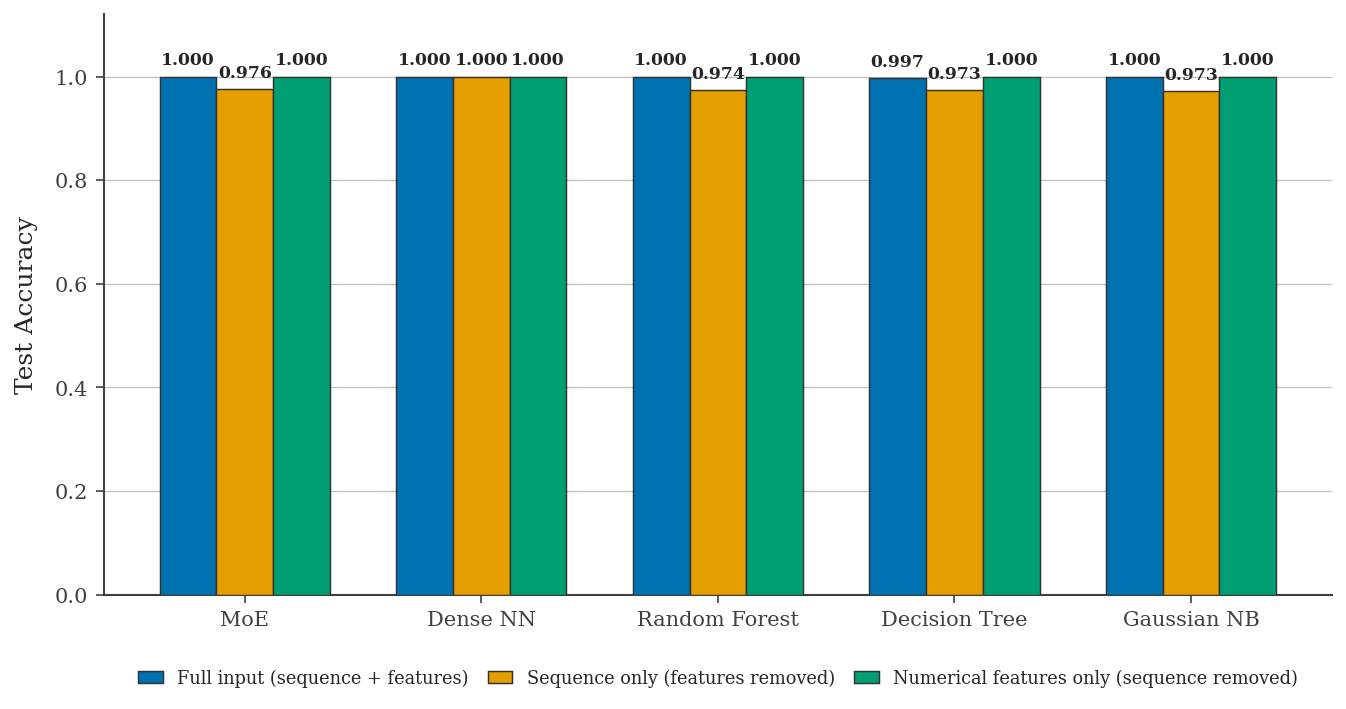


Saved: /content/drive/MyDrive/riboMoE_outputs/ablation/input_source_ablation_all5_paper.png
Saved: /content/drive/MyDrive/riboMoE_outputs/ablation/input_source_ablation_all5_paper.pdf


In [ ]:
"""
paper-ready input-source ablation plot

conditions:
1) full input = numerical features + real sequence
2) sequence only = numerical features zeroed, real sequence retained
3) numerical features only = numerical features retained,
   sequence replaced with identical dummy A sequence
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl


"""
global publication style
"""
mpl.rcParams.update({
    "axes.linewidth": 1.0,
    "axes.edgecolor": "0.25",
    "axes.labelcolor": "0.15",
    "text.color": "0.15",
    "xtick.color": "0.25",
    "ytick.color": "0.25",
    "figure.dpi": 150,
})


"""
load results
"""
cumulative_df = pd.read_csv(
    "/content/drive/MyDrive/riboMoE_outputs/ablation/"
    "cumulative_ablation_all5.csv"
)

numerical_only_df = pd.read_csv(
    "/content/drive/MyDrive/riboMoE_outputs/ablation/"
    "numerical_only_all5_models.csv"
)


"""
extract full-input and sequence-only results
"""
full_input_row = cumulative_df.loc[
    cumulative_df[
        "num_features_zeroed"
    ] == 0
].iloc[0]

sequence_only_row = cumulative_df.loc[
    cumulative_df[
        "num_features_zeroed"
    ] == 26
].iloc[0]


"""
model order
"""
model_names = [
    "MoE",
    "Dense NN",
    "Random Forest",
    "Decision Tree",
    "Gaussian NB",
]


"""
full-input accuracies
"""
full_input_accuracies = [
    full_input_row[
        "MoE_accuracy"
    ],
    full_input_row[
        "Dense_accuracy"
    ],
    full_input_row[
        "Random_Forest_accuracy"
    ],
    full_input_row[
        "Decision_Tree_accuracy"
    ],
    full_input_row[
        "Gaussian_NB_accuracy"
    ],
]


"""
sequence-only accuracies
"""
sequence_only_accuracies = [
    sequence_only_row[
        "MoE_accuracy"
    ],
    sequence_only_row[
        "Dense_accuracy"
    ],
    sequence_only_row[
        "Random_Forest_accuracy"
    ],
    sequence_only_row[
        "Decision_Tree_accuracy"
    ],
    sequence_only_row[
        "Gaussian_NB_accuracy"
    ],
]


"""
numerical-features-only accuracies
"""
numerical_only_df = (
    numerical_only_df
    .set_index(
        "Model"
    )
    .loc[
        model_names
    ]
    .reset_index()
)

numerical_only_accuracies = (
    numerical_only_df[
        "Accuracy"
    ]
    .to_numpy()
)


"""
comparison dataframe
"""
comparison_df = pd.DataFrame({
    "Model":
        model_names,

    "Full input (sequence + features)":
        full_input_accuracies,

    "Sequence only (features removed)":
        sequence_only_accuracies,

    "Numerical features only (sequence removed)":
        numerical_only_accuracies,
})

print(
    comparison_df.to_string(
        index=False
    )
)


"""
save comparison table
"""
comparison_df.to_csv(
    "/content/drive/MyDrive/riboMoE_outputs/ablation/"
    "input_source_comparison_all5.csv",
    index=False,
)


"""
plot
"""
x = np.arange(
    len(
        model_names
    )
)

bar_width = 0.24


"""
colorblind-safe palette
"""
COLOR_FULL = "#0072B2"
COLOR_SEQ = "#E69F00"
COLOR_NUM = "#009E73"
EDGE = "0.2"


fig, ax = plt.subplots(
    figsize=(
        9.2,
        5.3
    )
)


bars_full = ax.bar(
    x - bar_width,
    full_input_accuracies,
    width=bar_width,
    label="Full input (sequence + features)",
    color=COLOR_FULL,
    edgecolor=EDGE,
    linewidth=0.7,
    zorder=3,
)


bars_sequence = ax.bar(
    x,
    sequence_only_accuracies,
    width=bar_width,
    label="Sequence only (features removed)",
    color=COLOR_SEQ,
    edgecolor=EDGE,
    linewidth=0.7,
    zorder=3,
)


bars_numerical = ax.bar(
    x + bar_width,
    numerical_only_accuracies,
    width=bar_width,
    label="Numerical features only (sequence removed)",
    color=COLOR_NUM,
    edgecolor=EDGE,
    linewidth=0.7,
    zorder=3,
)


"""
axis formatting
"""
ax.set_ylabel(
    "Test Accuracy",
    fontsize=12,
    labelpad=8
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    model_names,
    fontsize=11
)

ax.set_ylim(
    0.0,
    1.12
)

ax.set_yticks(
    np.arange(
        0,
        1.01,
        0.2
    )
)

ax.tick_params(
    axis="both",
    labelsize=10,
    length=4
)

ax.grid(
    axis="y",
    color="0.75",
    linewidth=0.6,
    zorder=0
)

ax.set_axisbelow(
    True
)


"""
clean spines
"""
for spine in (
    "top",
    "right"
):

    ax.spines[
        spine
    ].set_visible(
        False
    )


for spine in (
    "left",
    "bottom"
):

    ax.spines[
        spine
    ].set_linewidth(
        1.0
    )

    ax.spines[
        spine
    ].set_color(
        "0.25"
    )


"""
value labels
"""
def add_labels(
    bars
):

    for bar in bars:

        height = (
            bar.get_height()
        )

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            height + 0.015,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=8.3,
            fontweight="bold",
            color="0.15",
        )


add_labels(
    bars_full
)

add_labels(
    bars_sequence
)

add_labels(
    bars_numerical
)


"""
legend below plot
"""
ax.legend(
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        -0.10
    ),
    ncol=3,
    frameon=False,
    fontsize=8.5,
    handlelength=1.4,
    columnspacing=1.1,
)


"""
layout
"""
fig.subplots_adjust(
    top=0.95,
    left=0.08,
    right=0.97,
    bottom=0.22
)


"""
save figure
"""
figure_path_png = (
    "/content/drive/MyDrive/"
    "riboMoE_outputs/ablation/"
    "input_source_ablation_all5_paper.png"
)

figure_path_pdf = (
    "/content/drive/MyDrive/"
    "riboMoE_outputs/ablation/"
    "input_source_ablation_all5_paper.pdf"
)

plt.savefig(
    figure_path_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    figure_path_pdf,
    bbox_inches="tight"
)

plt.show()


print(
    "\nSaved:",
    figure_path_png
)

print(
    "Saved:",
    figure_path_pdf
)

In [ ]:
"""
gaussian naive bayes
"""

from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler


def run_gaussian_nb(
    X_train,
    X_test
):

    scaler = StandardScaler()

    X_train_scaled = (
        scaler.fit_transform(
            X_train
        )
    )

    X_test_scaled = (
        scaler.transform(
            X_test
        )
    )

    model = GaussianNB(
        var_smoothing=1e-9
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    predictions = model.predict(
        X_test_scaled
    )

    return calculate_metrics(
        y_test,
        predictions
    )

In [ ]:
"""
setup for numerical-only experiment
"""

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split


"""
paths
"""
DATA_PATH = "/content/drive/MyDrive/balanced_dataset.csv"

OUTPUT_DIR = (
    "/content/drive/MyDrive/"
    "riboMoE_outputs/ablation"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


"""
load dataset
"""
df = (
    pd.read_csv(
        DATA_PATH
    )
    .dropna(
        subset=["label"]
    )
    .reset_index(
        drop=True
    )
)

print(
    "Dataset shape:",
    df.shape
)

print(
    "\nLabels:"
)

print(
    df["label"].value_counts()
)


"""
numerical features
"""
NUMERICAL_FEATURES = [
    "salt_molarity",
    "temperature (Celsius)",
    "trigger_target_binding_percentage",
    "switch_energy",
    "target_energy",
    "reporter_energy",
    "complex_energy",
    "switch_gc",
    "switch_at",
    "target_gc",
    "target_at",
    "reporter_gc",
    "reporter_at",
    "complex_gc",
    "complex_at",
    "switch_ensemble_defect",
    "target_ensemble_defect",
    "reporter_ensemble_defect",
    "complex_ensemble_defect",
    "switch_single_strandedness",
    "target_single_strandedness",
    "reporter_single_strandedness",
    "complex_single_strandedness",
    "trigger_single_strandedness",
    "rbs_location",
    "loop_energy"
]

print(
    "\nNumber of numerical features:",
    len(
        NUMERICAL_FEATURES
    )
)


"""
same train/test split
"""
y = (
    df["label"]
    .astype(int)
    .to_numpy()
)

all_indices = np.arange(
    len(df)
)

train_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=42
)

print(
    "\nTrain samples:",
    len(
        train_indices
    )
)

print(
    "Test samples:",
    len(
        test_indices
    )
)

Dataset shape: (55024, 54)

Labels:
label
0.0    27512
1.0    27512
Name: count, dtype: int64

Number of numerical features: 26

Train samples: 44019
Test samples: 11005


['zeroed_feature', 'MoE_accuracy', 'MoE_f1', 'Dense_accuracy', 'Dense_f1', 'Random_Forest_accuracy', 'Random_Forest_f1', 'Decision_Tree_accuracy', 'Decision_Tree_f1', 'Gaussian_NB_accuracy', 'Gaussian_NB_f1']


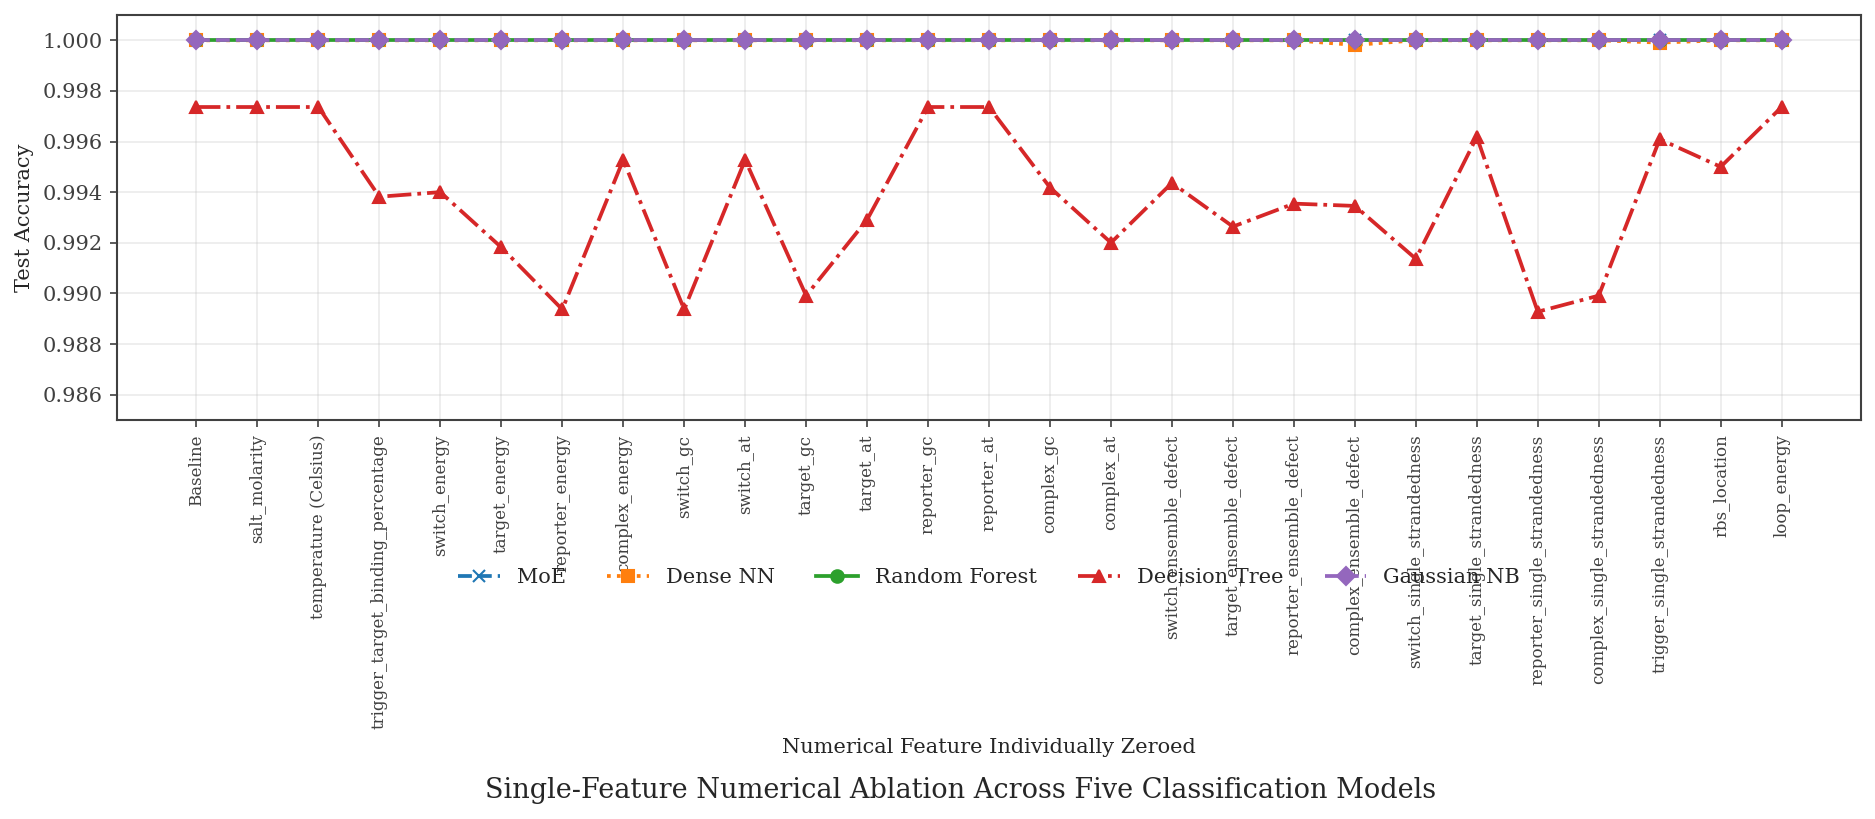


Saved: /content/drive/MyDrive/riboMoE_outputs/ablation/single_feature_ablation_all5_supplementary.png


In [ ]:
"""
single-feature ablation plot
all five classification models
"""

import pandas as pd
import matplotlib.pyplot as plt


"""
load single-feature ablation results
"""
single_df = pd.read_csv(
    "/content/drive/MyDrive/riboMoE_outputs/ablation/"
    "single_feature_ablation.csv"
)


"""
check available columns
"""
print(
    single_df.columns.tolist()
)


"""
models and result columns
"""
models = {
    "MoE": "MoE_accuracy",
    "Dense NN": "Dense_accuracy",
    "Random Forest": "Random_Forest_accuracy",
    "Decision Tree": "Decision_Tree_accuracy",
    "Gaussian NB": "Gaussian_NB_accuracy"
}


"""
make sure all five result columns exist
"""
missing_columns = [
    column
    for column in models.values()
    if column not in single_df.columns
]

if missing_columns:

    raise ValueError(
        "Missing columns: "
        + ", ".join(
            missing_columns
        )
    )


"""
x-axis labels
"""
features = (
    single_df[
        "zeroed_feature"
    ]
    .astype(str)
    .tolist()
)

x = range(
    len(features)
)


"""
plot
"""
fig, ax = plt.subplots(
    figsize=(
        15,
        6
    )
)


ax.plot(
    x,
    single_df[
        "MoE_accuracy"
    ],
    marker="x",
    linestyle="--",
    linewidth=1.8,
    label="MoE"
)

ax.plot(
    x,
    single_df[
        "Dense_accuracy"
    ],
    marker="s",
    linestyle=":",
    linewidth=1.8,
    label="Dense NN"
)

ax.plot(
    x,
    single_df[
        "Random_Forest_accuracy"
    ],
    marker="o",
    linestyle="-",
    linewidth=1.8,
    label="Random Forest"
)

ax.plot(
    x,
    single_df[
        "Decision_Tree_accuracy"
    ],
    marker="^",
    linestyle="-.",
    linewidth=1.8,
    label="Decision Tree"
)

ax.plot(
    x,
    single_df[
        "Gaussian_NB_accuracy"
    ],
    marker="D",
    linestyle="--",
    linewidth=1.8,
    label="Gaussian NB"
)


"""
formatting
"""
ax.set_xlabel(
    "Numerical Feature Individually Zeroed"
)

ax.set_ylabel(
    "Test Accuracy"
)

ax.set_xticks(
    list(
        x
    )
)

ax.set_xticklabels(
    features,
    rotation=90,
    fontsize=8
)

ax.set_ylim(
    0.985,
    1.001
)

ax.grid(
    axis="both",
    alpha=0.25
)

ax.set_axisbelow(
    True
)


"""
legend below graph
"""
ax.legend(
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        -0.32
    ),
    ncol=5,
    frameon=False
)


"""
title below legend
"""
fig.text(
    0.5,
    0.01,
    "Single-Feature Numerical Ablation Across Five Classification Models",
    ha="center",
    fontsize=13
)


"""
make room for labels and legend
"""
plt.subplots_adjust(
    bottom=0.43
)


"""
save
"""
figure_path = (
    "/content/drive/MyDrive/"
    "riboMoE_outputs/ablation/"
    "single_feature_ablation_all5_supplementary.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "\nSaved:",
    figure_path
)